# Lab-work #2

First name     - Maksym

Second name    - Maliutin

Group          - CS-31

# Task description

## Overall description

In this work you'll train your ability to understand models predictions, debug models, made conclusions.
You will try to use `Ceteris Paribus` (`CP`), `Individual Conditional Expectation` (`ICE`), `Partial Dependence Plot` (`PDP`), and `SHAP` for explaining your model predictions on the local (for the specific cases) and on the global level.

`WARNING`: usually we conduct analyzing ML model's interpretation on the test set (but what the difference? try to find out it manually).

## *Instructions for the work*

1. Carefully analyze example from this notebook.
2. Choose a dataset which you like the most (or just using your # in group list), also you're free to use models and data from your previous works. And you can use dataset either for classification (binary or multiclass classification is a valid ones) and regression (or even timeseries forecasting)
3. Train 2-3 models on the selected data (it mush be 1 ANN model, and 1-2 any other models for comparison (it could be any model: Linear, Decision Trees, XGBoost, SVM, ...)
4. Select some examples from the test set and build a CP plot and from the training set too. (Are the plots differs?)
5. Build ICE-plots for the same features used in CP plots (are they differ for different models and different sets (train and test)).
6. Build PDP plots for a few features (on the same plot for different models).
7. Working with SHAP, perform analyzing SHAPleay values.
8. Try to answer the question: if the SHAP method differs from the other presented methods?
9. Do NOT forget to leave comments on the each stage of your work.

## Important

1. Do NOT solve the problem in a single cell, such work will be worth 0. If you struggle with Jupyter Notebook just ask for help teacher or your friends. Also, you can solve the lab work in .py files, but provide your report with in .pdf file in the similar format.
2. Do NOT try to steal others works. This year I'll try to consider this. And identical works will be worth 0 too.
3. You can (and probably should) solve the task of the lab work in the separate .ipynb file. Just take this file, clear my solution and replace it with your own.

# Dataset Choice

## Selected Dataset: NASA Asteroids Classification

Dataset contains information about near-Earth asteroids (NEOs) with the main goal of predicting whether an asteroid is hazardous or not.

**Data source**: `nasa.csv`

**Task type**: Binary Classification

**Target variable**: `Hazardous` (True/False)

**Key features**:
- Absolute Magnitude
- Estimated Diameter (min/max in different units)
- Relative Velocity
- Orbital parameters (Eccentricity, Semi Major Axis, Inclination, etc.)
- Distance at closest approach

This dataset is suitable for interpretability analysis as:
1. Binary classification problem (clear target)
2. Good mix of numerical features
3. Real-world problem with business value

# 1. Installing & Importing Dependencies

In [1]:
%pip install numpy==2.3.3
%pip install pandas==2.3.2
%pip install matplotlib==3.10.6
%pip install seaborn==0.13.2
%pip install scikit-learn==1.7.2
%pip install scipy==1.15.2
%pip install tensorflow==2.20.0
%pip install shap
%pip install tqdm

   ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
   ------ --------------------------------- 2.1/12.8 MB 10.7 MB/s eta 0:00:02
   -------------- ------------------------- 4.7/12.8 MB 11.9 MB/s eta 0:00:01
   ---------------------- ----------------- 7.3/12.8 MB 11.6 MB/s eta 0:00:01
   ------------------------------- -------- 10.0/12.8 MB 11.7 MB/s eta 0:00:01
   -------------------------------------- - 12.3/12.8 MB 11.7 MB/s eta 0:00:01
   ---------------------------------------- 12.8/12.8 MB 11.4 MB/s  0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.2
    Uninstalling numpy-2.4.2:
      Successfully uninstalled numpy-2.4.2
Note: you may need to restart the kernel to use updated packages.
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   ---- ----------------------------------- 1.3/11.0 MB 7.4 MB/s eta 0:00:02
   ------------- -------------------------- 3.7/11.0 MB 9.9 MB/s eta 0:00:01
   ---------------------

In [2]:
# Import required libraries
import numpy as np
import pandas as pd
from tqdm import tqdm

# Preprocessing
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

# Models
import tensorflow as tf
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')

# Interpretability
import shap

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("All libraries imported successfully!")

All libraries imported successfully!


# 2. Load & Explore the Data

In [3]:
# Load the NASA asteroids dataset
df = pd.read_csv('nasa.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (4687, 40)

First few rows:


,Neo Reference ID,Name,Absolute Magnitude,Est Dia in KM(min),Est Dia in KM(max),Est Dia in M(min),Est Dia in M(max),Est Dia in Miles(min),Est Dia in Miles(max),Est Dia in Feet(min),...,Asc Node Longitude,Orbital Period,Perihelion Distance,Perihelion Arg,Aphelion Dist,Perihelion Time,Mean Anomaly,Mean Motion,Equinox,Hazardous
0,3703080,3703080,21.6,0.127220,0.284472,127.219879,284.472297,0.079051,0.176763,417.388066,...,314.373913,609.599786,0.808259,57.257470,2.005764,2.458162e+06,264.837533,0.590551,J2000,True
1,3723955,3723955,21.3,0.146068,0.326618,146.067964,326.617897,0.090762,0.202951,479.225620,...,136.717242,425.869294,0.718200,313.091975,1.497352,2.457795e+06,173.741112,0.845330,J2000,False
2,2446862,2446862,20.3,0.231502,0.517654,231.502122,517.654482,0.143849,0.321655,759.521423,...,259.475979,643.580228,0.950791,248.415038,1.966857,2.458120e+06,292.893654,0.559371,J2000,True
3,3092506,3092506,27.4,0.008801,0.019681,8.801465,19.680675,0.005469,0.012229,28.876199,...,57.173266,514.082140,0.983902,18.707701,1.527904,2.457902e+06,68.741007,0.700277,J2000,False
4,3514799,3514799,21.6,0.127220,0.284472,127.219879,284.472297,0.079051,0.176763,417.388066,...,84.629307,495.597821,0.967687,158.263596,1.483543,2.457814e+06,135.142133,0.726395,J2000,True


In [4]:
# Check data types and missing values
print("Data Info:")
print(df.info())
print(f"\nMissing values:")
print(df.isnull().sum())
print(f"\nBasic Statistics:")
df.describe()

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4687 entries, 0 to 4686
Data columns (total 40 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Neo Reference ID              4687 non-null   int64  
 1   Name                          4687 non-null   int64  
 2   Absolute Magnitude            4687 non-null   float64
 3   Est Dia in KM(min)            4687 non-null   float64
 4   Est Dia in KM(max)            4687 non-null   float64
 5   Est Dia in M(min)             4687 non-null   float64
 6   Est Dia in M(max)             4687 non-null   float64
 7   Est Dia in Miles(min)         4687 non-null   float64
 8   Est Dia in Miles(max)         4687 non-null   float64
 9   Est Dia in Feet(min)          4687 non-null   float64
 10  Est Dia in Feet(max)          4687 non-null   float64
 11  Close Approach Date           4687 non-null   object 
 12  Epoch Date Close Approach     4687 non-null   int64

,Neo Reference ID,Name,Absolute Magnitude,Est Dia in KM(min),Est Dia in KM(max),Est Dia in M(min),Est Dia in M(max),Est Dia in Miles(min),Est Dia in Miles(max),Est Dia in Feet(min),...,Semi Major Axis,Inclination,Asc Node Longitude,Orbital Period,Perihelion Distance,Perihelion Arg,Aphelion Dist,Perihelion Time,Mean Anomaly,Mean Motion
count,4.687000e+03,4.687000e+03,4687.000000,4687.000000,4687.000000,4687.000000,4687.000000,4687.000000,4687.000000,4687.000000,...,4687.000000,4687.000000,4687.000000,4687.000000,4687.000000,4687.000000,4687.000000,4.687000e+03,4687.000000,4687.000000
mean,3.272298e+06,3.272298e+06,22.267865,0.204604,0.457509,204.604203,457.508906,0.127135,0.284283,671.273653,...,1.400264,13.373844,172.157275,635.582076,0.813383,183.932151,1.987144,2.457728e+06,181.167927,0.738242
std,5.486011e+05,5.486011e+05,2.890972,0.369573,0.826391,369.573402,826.391249,0.229642,0.513496,1212.511199,...,0.524154,10.936227,103.276777,370.954727,0.242059,103.513035,0.951519,9.442264e+02,107.501623,0.342627
min,2.000433e+06,2.000433e+06,11.160000,0.001011,0.002260,1.010543,2.259644,0.000628,0.001404,3.315431,...,0.615920,0.014513,0.001941,176.557161,0.080744,0.006918,0.803765,2.450100e+06,0.003191,0.086285
25%,3.097594e+06,3.097594e+06,20.100000,0.033462,0.074824,33.462237,74.823838,0.020792,0.046493,109.784247,...,1.000635,4.962341,83.081208,365.605031,0.630834,95.625916,1.266059,2.457815e+06,87.006918,0.453289
50%,3.514799e+06,3.514799e+06,21.900000,0.110804,0.247765,110.803882,247.765013,0.068850,0.153954,363.529809,...,1.240981,10.311836,172.625393,504.947292,0.833153,189.761641,1.618195,2.457973e+06,185.718889,0.712946
75%,3.690060e+06,3.690060e+06,24.500000,0.253837,0.567597,253.837029,567.596853,0.157727,0.352688,832.798679,...,1.678364,19.511681,255.026909,794.195972,0.997227,271.777557,2.451171,2.458108e+06,276.531946,0.984669
max,3.781897e+06,3.781897e+06,32.100000,15.579552,34.836938,15579.552413,34836.938254,9.680682,21.646663,51114.018738,...,5.072008,75.406667,359.905890,4172.231343,1.299832,359.993098,8.983852,2.458839e+06,359.917991,2.039000


Target Variable Distribution:
Hazardous
False    3932
True      755
Name: count, dtype: int64

Percentages:
Hazardous
False    83.891615
True     16.108385
Name: proportion, dtype: float64


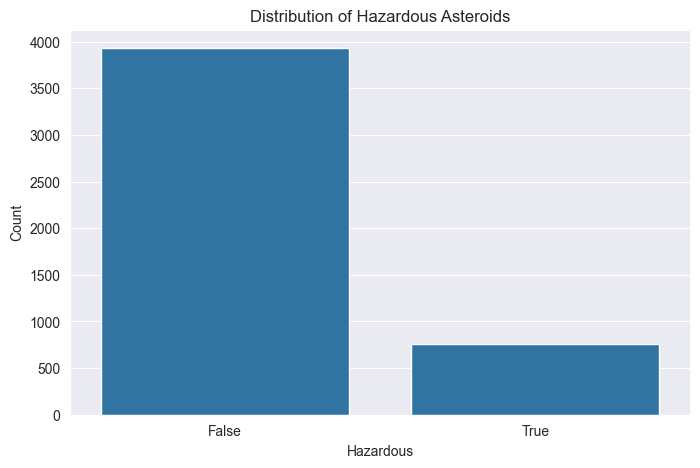

In [5]:
# Check target variable distribution
print("Target Variable Distribution:")
print(df['Hazardous'].value_counts())
print(f"\nPercentages:")
print(df['Hazardous'].value_counts(normalize=True) * 100)

# Visualize class distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Hazardous')
plt.title('Distribution of Hazardous Asteroids')
plt.xlabel('Hazardous')
plt.ylabel('Count')
plt.show()

# 3. Data Preprocessing & Feature Engineering

In [6]:
# Step 1: Select relevant numerical features
# Drop columns that are identifiers, dates, or redundant
drop_columns = [
    'Neo Reference ID', 'Name', 'Close Approach Date', 'Epoch Date Close Approach',
    'Orbit ID', 'Orbit Determination Date', 'Orbiting Body', 'Epoch Osculation',
    'Perihelion Time', 'Equinox'
]

df_processed = df.drop(columns=drop_columns)

print(f"Features after dropping identifiers: {df_processed.shape}")
print(f"Remaining columns: {list(df_processed.columns)}")

Features after dropping identifiers: (4687, 30)
Remaining columns: ['Absolute Magnitude', 'Est Dia in KM(min)', 'Est Dia in KM(max)', 'Est Dia in M(min)', 'Est Dia in M(max)', 'Est Dia in Miles(min)', 'Est Dia in Miles(max)', 'Est Dia in Feet(min)', 'Est Dia in Feet(max)', 'Relative Velocity km per sec', 'Relative Velocity km per hr', 'Miles per hour', 'Miss Dist.(Astronomical)', 'Miss Dist.(lunar)', 'Miss Dist.(kilometers)', 'Miss Dist.(miles)', 'Orbit Uncertainity', 'Minimum Orbit Intersection', 'Jupiter Tisserand Invariant', 'Eccentricity', 'Semi Major Axis', 'Inclination', 'Asc Node Longitude', 'Orbital Period', 'Perihelion Distance', 'Perihelion Arg', 'Aphelion Dist', 'Mean Anomaly', 'Mean Motion', 'Hazardous']


In [7]:
# Step 2: Check for missing values in remaining features
missing_values = df_processed.isnull().sum()
print("Missing values in remaining features:")
print(missing_values[missing_values > 0])

# Fill missing values with median (for numerical features)
df_processed = df_processed.fillna(df_processed.median())
print(f"\nMissing values after filling: {df_processed.isnull().sum().sum()}")

Missing values in remaining features:
Series([], dtype: int64)

Missing values after filling: 0


In [8]:
# Step 3: Separate features and target
X = df_processed.drop('Hazardous', axis=1)
y = df_processed['Hazardous'].astype(int)  # Convert to 0/1

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature names:")
print(list(X.columns))

Features shape: (4687, 29)
Target shape: (4687,)

Feature names:
['Absolute Magnitude', 'Est Dia in KM(min)', 'Est Dia in KM(max)', 'Est Dia in M(min)', 'Est Dia in M(max)', 'Est Dia in Miles(min)', 'Est Dia in Miles(max)', 'Est Dia in Feet(min)', 'Est Dia in Feet(max)', 'Relative Velocity km per sec', 'Relative Velocity km per hr', 'Miles per hour', 'Miss Dist.(Astronomical)', 'Miss Dist.(lunar)', 'Miss Dist.(kilometers)', 'Miss Dist.(miles)', 'Orbit Uncertainity', 'Minimum Orbit Intersection', 'Jupiter Tisserand Invariant', 'Eccentricity', 'Semi Major Axis', 'Inclination', 'Asc Node Longitude', 'Orbital Period', 'Perihelion Distance', 'Perihelion Arg', 'Aphelion Dist', 'Mean Anomaly', 'Mean Motion']


In [9]:
# Step 4: Split data into train and test sets (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print(f"\nTraining set class distribution:")
print(y_train.value_counts(normalize=True) * 100)
print(f"\nTesting set class distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training set shape: (3749, 29)
Testing set shape: (938, 29)

Training set class distribution:
Hazardous
0    83.889037
1    16.110963
Name: proportion, dtype: float64

Testing set class distribution:
Hazardous
0    83.901919
1    16.098081
Name: proportion, dtype: float64


In [10]:
# Step 5: Normalize features using MinMaxScaler (0-1 range is better for neural networks)
scaler = MinMaxScaler(feature_range=(0, 1))
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

print(f"Scaling completed!")
print(f"\nTrain scaled data range:")
print(f"Min: {X_train_scaled.min().min():.4f}, Max: {X_train_scaled.max().max():.4f}")
print(f"Test scaled data range:")
print(f"Min: {X_test_scaled.min().min():.4f}, Max: {X_test_scaled.max().max():.4f}")

print(f"\nFirst few rows of scaled training data:")
X_train_scaled.head()

Scaling completed!

Train scaled data range:
Min: 0.0000, Max: 1.0000
Test scaled data range:
Min: -0.0287, Max: 1.6791

First few rows of scaled training data:


,Absolute Magnitude,Est Dia in KM(min),Est Dia in KM(max),Est Dia in M(min),Est Dia in M(max),Est Dia in Miles(min),Est Dia in Miles(max),Est Dia in Feet(min),Est Dia in Feet(max),Relative Velocity km per sec,...,Eccentricity,Semi Major Axis,Inclination,Asc Node Longitude,Orbital Period,Perihelion Distance,Perihelion Arg,Aphelion Dist,Mean Anomaly,Mean Motion
0,0.360076,0.030983,0.030983,0.030983,0.030983,0.030983,0.030983,0.030983,0.030983,0.309823,...,0.551414,0.551901,0.068527,0.474972,0.459548,0.862946,0.401886,0.499900,0.931546,0.075126
1,0.603629,0.002900,0.002900,0.002900,0.002900,0.002900,0.002900,0.002900,0.002900,0.132107,...,0.507490,0.532753,0.026820,0.120815,0.439354,0.913191,0.765195,0.466648,0.319002,0.080998
2,0.660936,0.001641,0.001641,0.001641,0.001641,0.001641,0.001641,0.001641,0.001641,0.283765,...,0.317955,0.133420,0.327393,0.897671,0.084365,0.513301,0.204738,0.097865,0.645579,0.428448
3,0.737345,0.000752,0.000752,0.000752,0.000752,0.000752,0.000752,0.000752,0.000752,0.134109,...,0.173490,0.101021,0.107353,0.163514,0.061983,0.555933,0.881535,0.051109,0.497491,0.511062
4,0.732569,0.000790,0.000790,0.000790,0.000790,0.000790,0.000790,0.000790,0.000790,0.160238,...,0.258236,0.165263,0.043121,0.352913,0.107443,0.621504,0.241922,0.110157,0.878907,0.364585


# 4. Train Machine Learning Models

## 4.1. Artificial Neural Network (ANN) Model

### Model Architecture:
- Input layer: number of features
- Hidden layer 1: 128 units with ReLU activation and Dropout(0.3)
- Hidden layer 2: 64 units with ReLU activation and Dropout(0.3)
- Hidden layer 3: 32 units with ReLU activation
- Output layer: 1 unit with Sigmoid activation (for binary classification)
- Optimizer: Adam
- Loss: Binary Crossentropy

In [11]:
# Build the ANN model
ann_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    
    tf.keras.layers.Dense(128, activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.Dropout(0.3),
    
    tf.keras.layers.Dense(64, activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.Dropout(0.3),
    
    tf.keras.layers.Dense(32, activation='relu', kernel_initializer='he_normal'),
    
    tf.keras.layers.Dense(1, activation='sigmoid')  # Binary classification
])

# Compile the model
ann_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

print("ANN Model Summary:")
ann_model.summary()

ANN Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         3,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,209 (55.50 KB)

 Trainable params: 14,209 (55.50 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Train the ANN model
print("Training ANN model...")
ann_history = ann_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    verbose=1,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        )
    ]
)

Training ANN model...
Epoch 1/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8423 - auc: 0.7206 - loss: 0.3930 - val_accuracy: 0.8360 - val_auc: 0.8890 - val_loss: 0.3242
Epoch 2/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8489 - auc: 0.8675 - loss: 0.3081 - val_accuracy: 0.8720 - val_auc: 0.9283 - val_loss: 0.2732
Epoch 3/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8690 - auc: 0.8943 - loss: 0.2796 - val_accuracy: 0.9027 - val_auc: 0.9446 - val_loss: 0.2425
Epoch 4/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8866 - auc: 0.9240 - loss: 0.2433 - val_accuracy: 0.9133 - val_auc: 0.9612 - val_loss: 0.2186
Epoch 5/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9003 - auc: 0.9369 - loss: 0.2235 - val_accuracy: 0.9227 - val_auc: 0.9683 - val_loss: 0.1971
Epoch 6/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9093 - auc: 0.9418 - loss: 0.2162 - val_accuracy: 0.9373 - val_auc: 0.9729 - val_loss: 0.1750
Epoch 7/30
94/94 ━━━━━━━━━━━━━

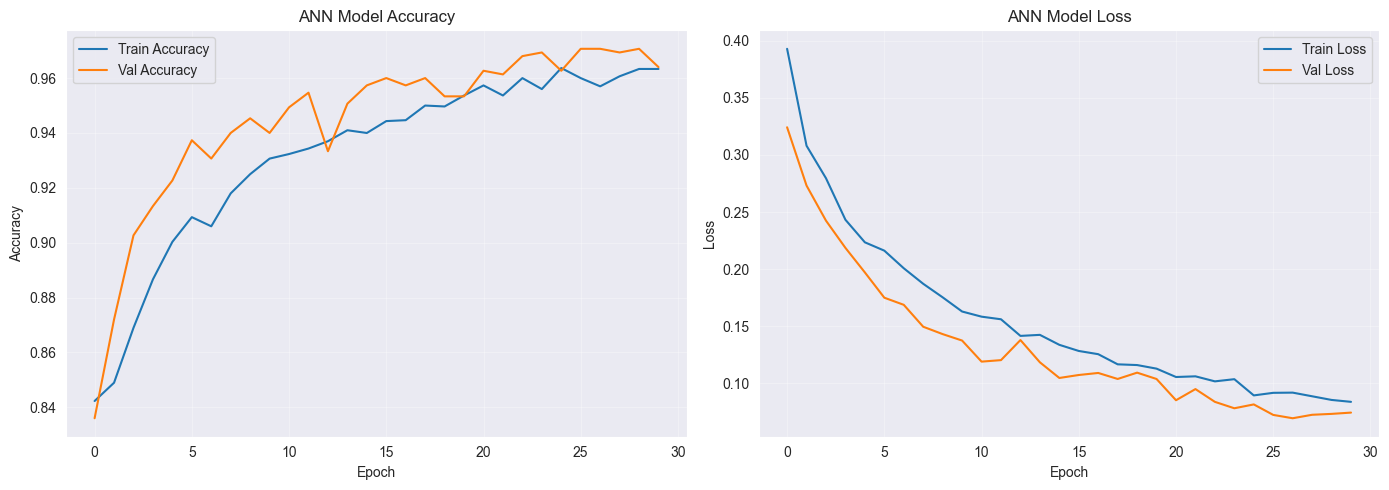

ANN Model trained successfully!


In [13]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(ann_history.history['accuracy'], label='Train Accuracy')
axes[0].plot(ann_history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('ANN Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(ann_history.history['loss'], label='Train Loss')
axes[1].plot(ann_history.history['val_loss'], label='Val Loss')
axes[1].set_title('ANN Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("ANN Model trained successfully!")

## 4.2. Logistic Regression Model

In [14]:
# Train Logistic Regression model
print("Training Logistic Regression model...")
lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)

# Make predictions on train and test sets
y_train_pred_lr = lr_model.predict(X_train_scaled)
y_test_pred_lr = lr_model.predict(X_test_scaled)

print("Logistic Regression model trained successfully!")
print(f"\nTraining Accuracy: {accuracy_score(y_train, y_train_pred_lr):.4f}")
print(f"Testing Accuracy: {accuracy_score(y_test, y_test_pred_lr):.4f}")

Training Logistic Regression model...
Logistic Regression model trained successfully!

Training Accuracy: 0.8976
Testing Accuracy: 0.8966


## 4.3. Support Vector Machine (SVM) Model

In [15]:
# Train SVM model
print("Training SVM model...")
svm_model = SVC(kernel='rbf', class_weight='balanced', random_state=42, probability=True)
svm_model.fit(X_train_scaled, y_train)

# Make predictions on train and test sets
y_train_pred_svm = svm_model.predict(X_train_scaled)
y_test_pred_svm = svm_model.predict(X_test_scaled)

print("SVM model trained successfully!")
print(f"\nTraining Accuracy: {accuracy_score(y_train, y_train_pred_svm):.4f}")
print(f"Testing Accuracy: {accuracy_score(y_test, y_test_pred_svm):.4f}")

Training SVM model...
SVM model trained successfully!

Training Accuracy: 0.8994
Testing Accuracy: 0.8945


## 4.4. Model Performance Comparison

In [16]:
# Evaluate ANN on test set
ann_train_loss, ann_train_acc, _ = ann_model.evaluate(X_train_scaled, y_train, verbose=0)
ann_test_loss, ann_test_acc, _ = ann_model.evaluate(X_test_scaled, y_test, verbose=0)

# Get predictions from ANN
y_train_pred_ann = (ann_model.predict(X_train_scaled, verbose=0) > 0.5).astype(int).flatten()
y_test_pred_ann = (ann_model.predict(X_test_scaled, verbose=0) > 0.5).astype(int).flatten()

# Create comparison table
comparison_data = {
    'Model': ['ANN', 'Logistic Regression', 'SVM'],
    'Train Accuracy': [
        accuracy_score(y_train, y_train_pred_ann),
        accuracy_score(y_train, y_train_pred_lr),
        accuracy_score(y_train, y_train_pred_svm)
    ],
    'Test Accuracy': [
        accuracy_score(y_test, y_test_pred_ann),
        accuracy_score(y_test, y_test_pred_lr),
        accuracy_score(y_test, y_test_pred_svm)
    ],
    'Train AUC': [
        roc_auc_score(y_train, ann_model.predict(X_train_scaled, verbose=0).flatten()),
        roc_auc_score(y_train, lr_model.predict_proba(X_train_scaled)[:, 1]),
        roc_auc_score(y_train, svm_model.predict_proba(X_train_scaled)[:, 1])
    ],
    'Test AUC': [
        roc_auc_score(y_test, ann_model.predict(X_test_scaled, verbose=0).flatten()),
        roc_auc_score(y_test, lr_model.predict_proba(X_test_scaled)[:, 1]),
        roc_auc_score(y_test, svm_model.predict_proba(X_test_scaled)[:, 1])
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n=== Model Performance Comparison ===")
print(comparison_df.to_string())

# Detailed classification reports
print("\n\n=== ANN Classification Report (Test Set) ===")
print(classification_report(y_test, y_test_pred_ann))

print("\n=== Logistic Regression Classification Report (Test Set) ===")
print(classification_report(y_test, y_test_pred_lr))

print("\n=== SVM Classification Report (Test Set) ===")
print(classification_report(y_test, y_test_pred_svm))


=== Model Performance Comparison ===
                 Model  Train Accuracy  Test Accuracy  Train AUC  Test AUC
0                  ANN        0.978394       0.974414   0.996802  0.993807
1  Logistic Regression        0.897573       0.896588   0.975132  0.972820
2                  SVM        0.899440       0.894456   0.987695  0.979413


=== ANN Classification Report (Test Set) ===
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       787
           1       0.95      0.89      0.92       151

    accuracy                           0.97       938
   macro avg       0.96      0.94      0.95       938
weighted avg       0.97      0.97      0.97       938


=== Logistic Regression Classification Report (Test Set) ===
              precision    recall  f1-score   support

           0       0.99      0.89      0.94       787
           1       0.62      0.94      0.75       151

    accuracy                           0.90       938
   macro

# 5. Ceteris Paribus (CP) Plots

## Analysis:

Ceteris Paribus plots show how the prediction of a model changes when we vary one feature while keeping all other features constant.

### Key Questions:
1. Are the CP profiles different for different models?
2. Do they differ between training and test sets?
3. What is the shape of the profiles (monotonic, non-linear, etc.)?

In [17]:
def plot_ceteris_paribus(sample_idx, feature_name, dataset_name, X_data, y_data):
    """
    Plot Ceteris Paribus profile for a specific sample and feature.
    
    Args:
        sample_idx: Index of the sample to analyze
        feature_name: Name of the feature to vary
        dataset_name: Name of the dataset (e.g., 'Train', 'Test')
        X_data: Feature data (DataFrame)
        y_data: Target data
    """
    # Get the instance
    instance = X_data.iloc[sample_idx].copy()
    actual_value = instance[feature_name]
    actual_target = y_data.iloc[sample_idx]
    
    # Create a range of values for the feature
    feature_range = np.linspace(X_data[feature_name].min(), X_data[feature_name].max(), 100)
    
    # Create synthetic data where only the feature changes
    synthetic_data = pd.DataFrame([instance.values] * len(feature_range), columns=X_data.columns)
    synthetic_data[feature_name] = feature_range
    
    # Get predictions from all three models
    prob_ann = ann_model.predict(synthetic_data, verbose=0).flatten()
    prob_lr = lr_model.predict_proba(synthetic_data)[:, 1]
    prob_svm = svm_model.predict_proba(synthetic_data)[:, 1]
    
    # Create the plot
    plt.figure(figsize=(12, 6))
    
    plt.plot(feature_range, prob_ann, linewidth=2.5, label='ANN', color='#e74c3c')
    plt.plot(feature_range, prob_lr, linewidth=2.5, label='Logistic Regression', color='#3498db', linestyle='--')
    plt.plot(feature_range, prob_svm, linewidth=2.5, label='SVM', color='#2ecc71', linestyle='-.')
    
    # Mark actual value
    plt.axvline(x=actual_value, color='red', alpha=0.6, linestyle=':', linewidth=2, 
                label=f'Actual value: {actual_value:.4f} (Target: {actual_target})')
    
    plt.title(f'Ceteris Paribus Plot: {feature_name}\nSample #{sample_idx} from {dataset_name} Set')
    plt.xlabel(f'{feature_name} (normalized values)')
    plt.ylabel('Predicted Probability of Hazardous (Class = 1)')
    plt.legend(loc='best', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

=== CETERIS PARIBUS ANALYSIS ===

CP Plot for TEST SET Sample #5:


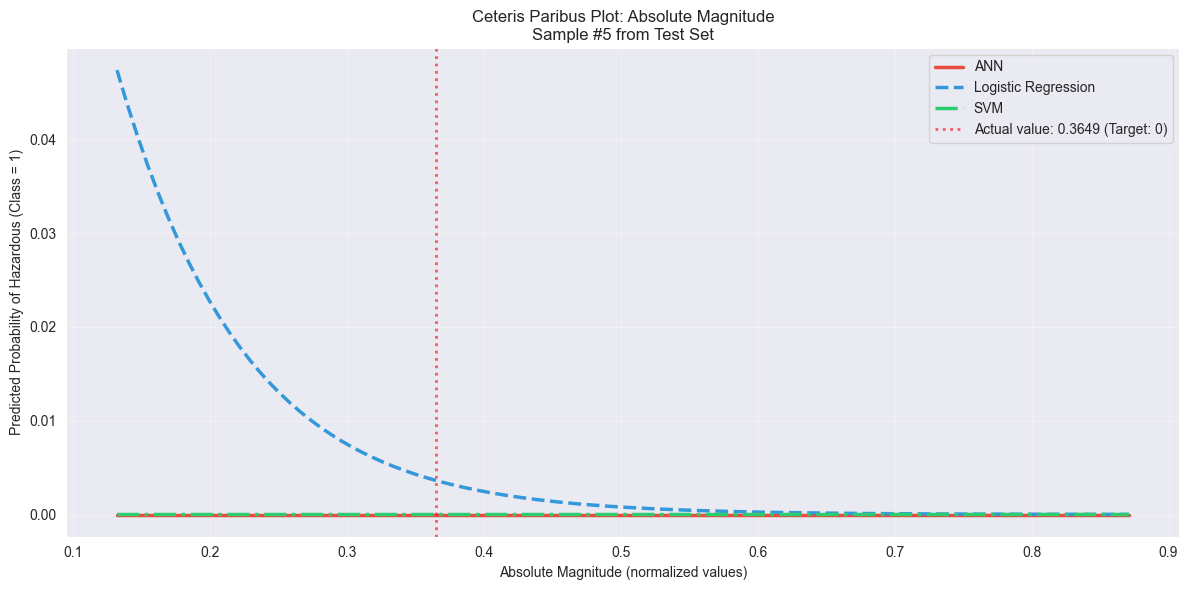

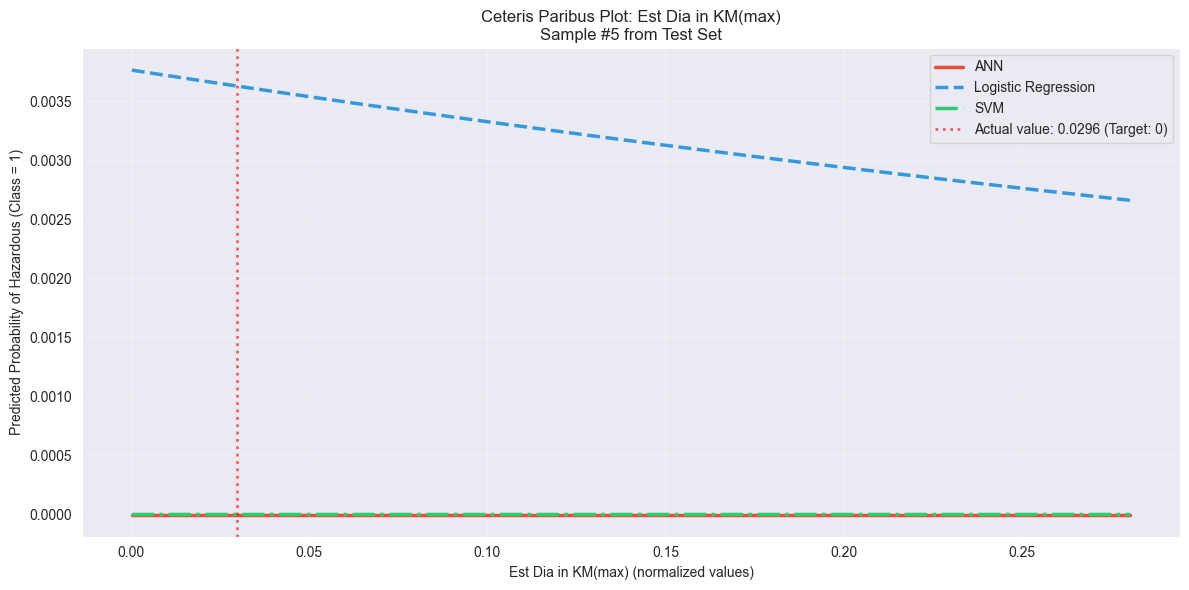

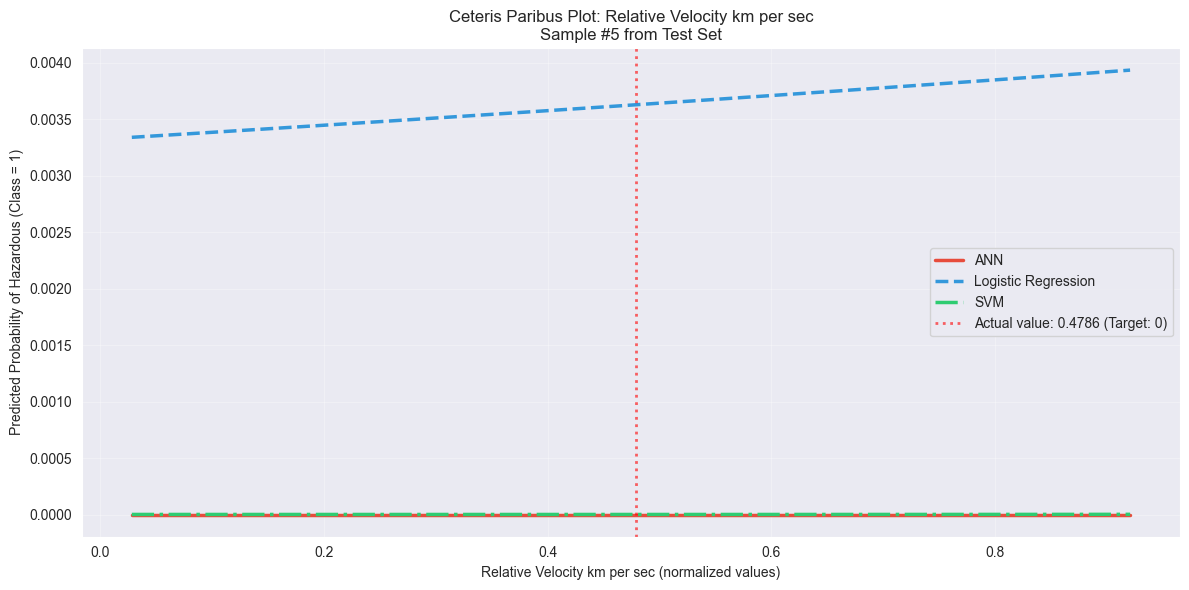

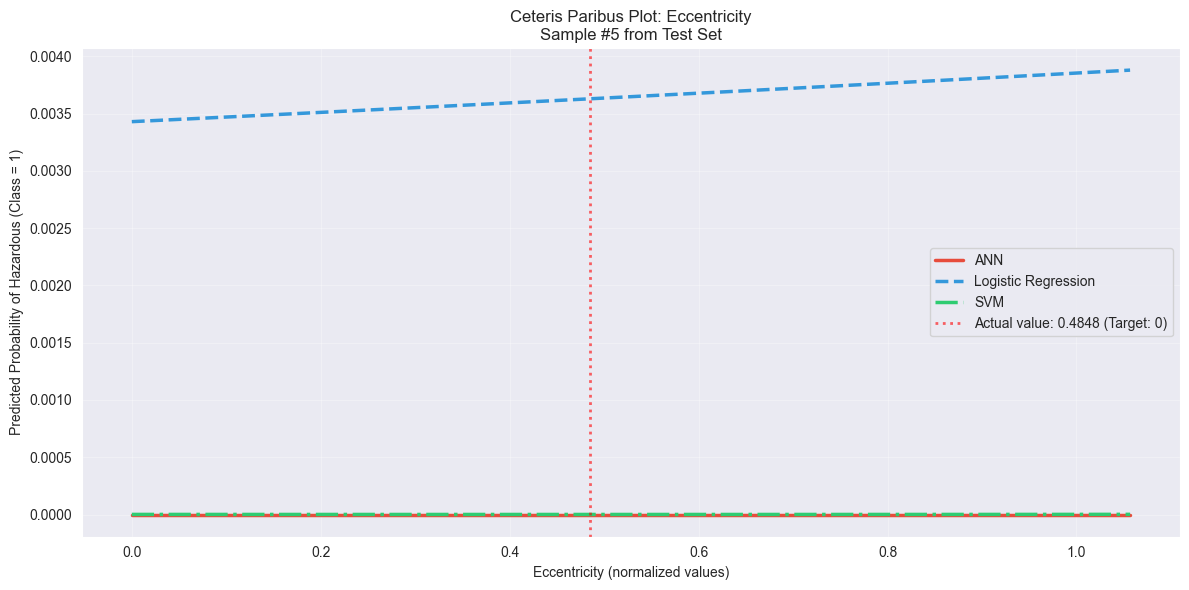

In [18]:
# Select interesting features for analysis
interesting_features = [
    'Absolute Magnitude',
    'Est Dia in KM(max)',
    'Relative Velocity km per sec',
    'Eccentricity'
]

# Plot CP for a test sample
print("=== CETERIS PARIBUS ANALYSIS ===")
print("\nCP Plot for TEST SET Sample #5:")
for feature in interesting_features:
    plot_ceteris_paribus(5, feature, 'Test', X_test_scaled, y_test)


CP Plot for TRAIN SET Sample #5:


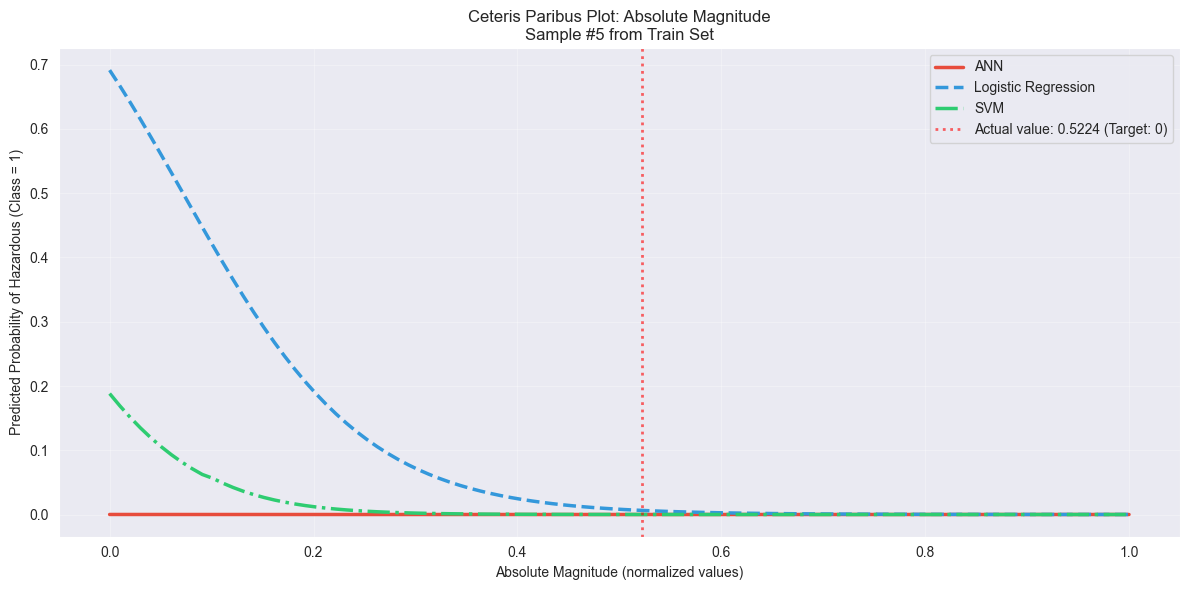

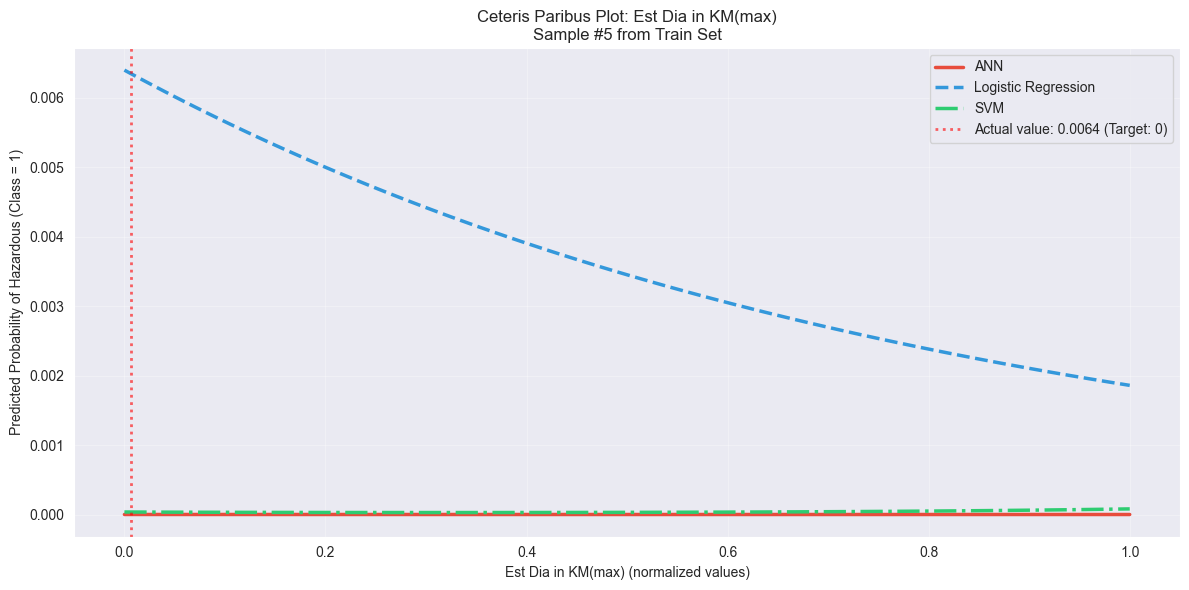

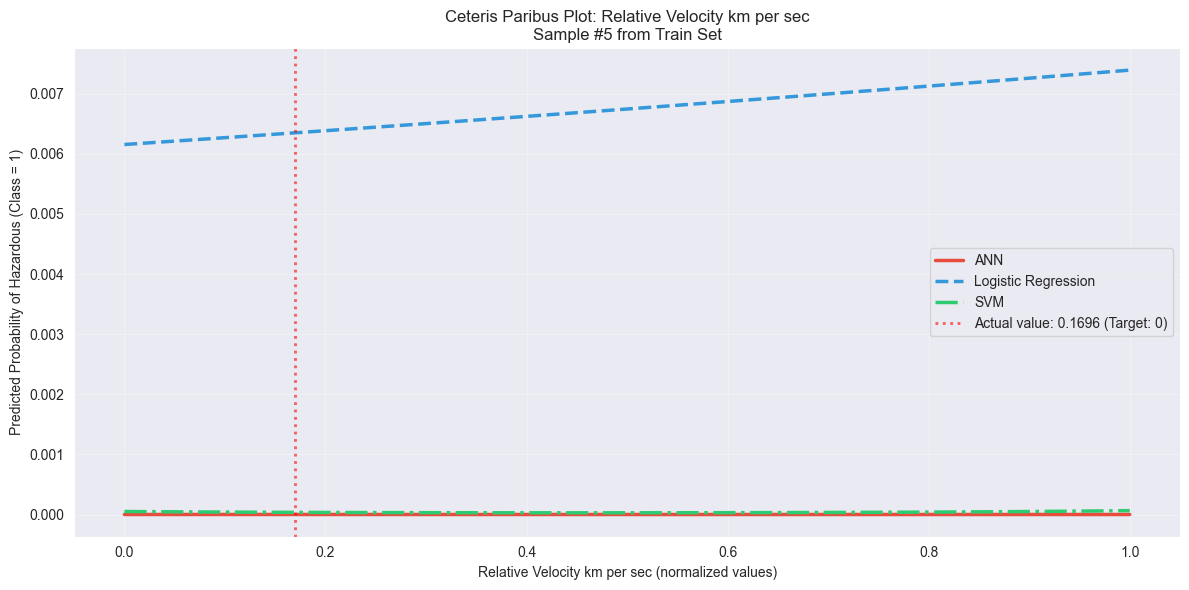

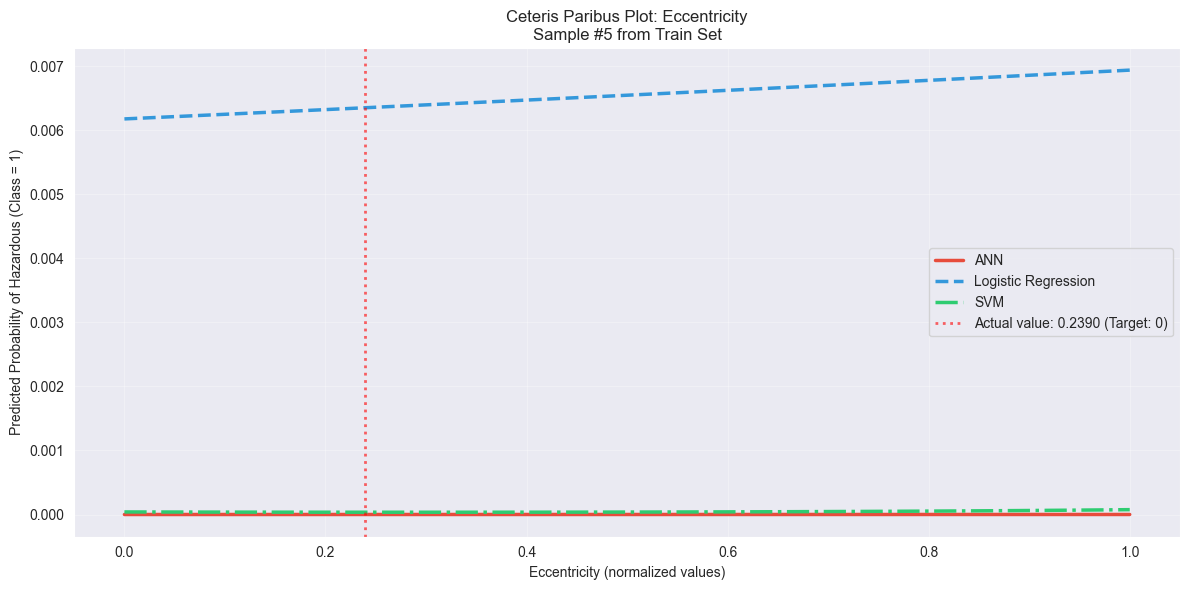

In [19]:
# Plot CP for a train sample
print("\nCP Plot for TRAIN SET Sample #5:")
for feature in interesting_features:
    plot_ceteris_paribus(5, feature, 'Train', X_train_scaled, y_train)

### Observations from CP Plots

- **Differences between models**: for most features, `ANN` shows a more pronounced nonlinear response (jumps/plateaus), while `Logistic Regression` changes predictions more smoothly and almost monotonically. `SVM` is in between, but also shows local nonlinear behavior.
- **Most sensitive features**: the largest probability changes are observed for `Absolute Magnitude` and `Eccentricity`; for some other features the effect is weaker or more local.
- **Train vs Test**: profile shapes are generally similar on train and test, meaning the model applies similar rules on unseen data. Within the analyzed examples, this does not indicate obvious overfitting.
- **Local nature of CP**: profiles differ across individual objects, so CP should be interpreted as an explanation for a specific case, not as a global rule for the whole dataset.

# 6. Individual Conditional Expectation (ICE) Plots

## Analysis:

ICE plots show the conditional expectation for EACH individual sample separately (unlike CP which is for one sample).

By plotting many individual lines, we can see:
1. The heterogeneity in model behavior across different instances
2. Whether relationships are consistent or instance-dependent
3. When averaged, ICE becomes a PDP (Partial Dependence Plot)

In [20]:
def plot_ice_curves(feature_name, dataset_name, X_data, y_data, n_samples=100):
    """
    Plot Individual Conditional Expectation curves for a feature.
    
    Args:
        feature_name: Name of the feature to analyze
        dataset_name: Name of the dataset (e.g., 'Train', 'Test')
        X_data: Feature data (DataFrame)
        y_data: Target data
        n_samples: Number of samples to plot (for readability)
    """
    # Sample data if too large
    if len(X_data) > n_samples:
        sample_indices = np.random.choice(len(X_data), n_samples, replace=False)
        X_sample = X_data.iloc[sample_indices].reset_index(drop=True)
        y_sample = y_data.iloc[sample_indices].reset_index(drop=True)
    else:
        X_sample = X_data.reset_index(drop=True)
        y_sample = y_data.reset_index(drop=True)
    
    # Create feature range
    feature_range = np.linspace(X_data[feature_name].min(), X_data[feature_name].max(), 100)
    
    # Store predictions for averaging
    all_prob_ann = []
    all_prob_lr = []
    all_prob_svm = []
    
    # Create figure with 3 subplots (one for each model)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    fig.suptitle(f'ICE Plots: Effect of {feature_name} on Hazard Prediction\n({dataset_name} Set, {len(X_sample)} samples)', 
                 fontsize=14, fontweight='bold')
    
    print(f"Generating ICE curves for {len(X_sample)} samples and {len(feature_range)} points...")
    
    # Generate ICE curves for each sample
    for i in tqdm(range(len(X_sample))):
        instance = X_sample.iloc[i].copy()
        
        # Create synthetic data
        synthetic_data = pd.DataFrame([instance.values] * len(feature_range), columns=X_data.columns)
        synthetic_data[feature_name] = feature_range
        
        # Get predictions
        prob_ann = ann_model.predict(synthetic_data, verbose=0).flatten()
        prob_lr = lr_model.predict_proba(synthetic_data)[:, 1]
        prob_svm = svm_model.predict_proba(synthetic_data)[:, 1]
        
        # Store for averaging
        all_prob_ann.append(prob_ann)
        all_prob_lr.append(prob_lr)
        all_prob_svm.append(prob_svm)
        
        # Plot individual lines with low alpha
        axes[0].plot(feature_range, prob_ann, color='#e74c3c', alpha=0.05)
        axes[1].plot(feature_range, prob_lr, color='#3498db', alpha=0.05)
        axes[2].plot(feature_range, prob_svm, color='#2ecc71', alpha=0.05)
    
    # Calculate and plot average (PDP)
    pdp_ann = np.mean(all_prob_ann, axis=0)
    pdp_lr = np.mean(all_prob_lr, axis=0)
    pdp_svm = np.mean(all_prob_svm, axis=0)
    
    axes[0].plot(feature_range, pdp_ann, color='black', linewidth=3, label='PDP (Average)', zorder=10)
    axes[1].plot(feature_range, pdp_lr, color='black', linewidth=3, label='PDP (Average)', zorder=10)
    axes[2].plot(feature_range, pdp_svm, color='black', linewidth=3, label='PDP (Average)', zorder=10)
    
    # Format plots
    titles = ['ANN', 'Logistic Regression', 'SVM']
    for j, ax in enumerate(axes):
        ax.set_title(titles[j], fontsize=12, fontweight='bold')
        ax.set_xlabel(f'{feature_name}')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best')
    
    axes[0].set_ylabel('Predicted Probability of Hazardous')
    plt.tight_layout()
    plt.show()
    
    print("ICE plots generated successfully!")

=== ICE PLOTS FOR TEST SET ===
Generating ICE curves for 80 samples and 100 points...


100%|██████████| 80/80 [00:04<00:00, 17.52it/s]


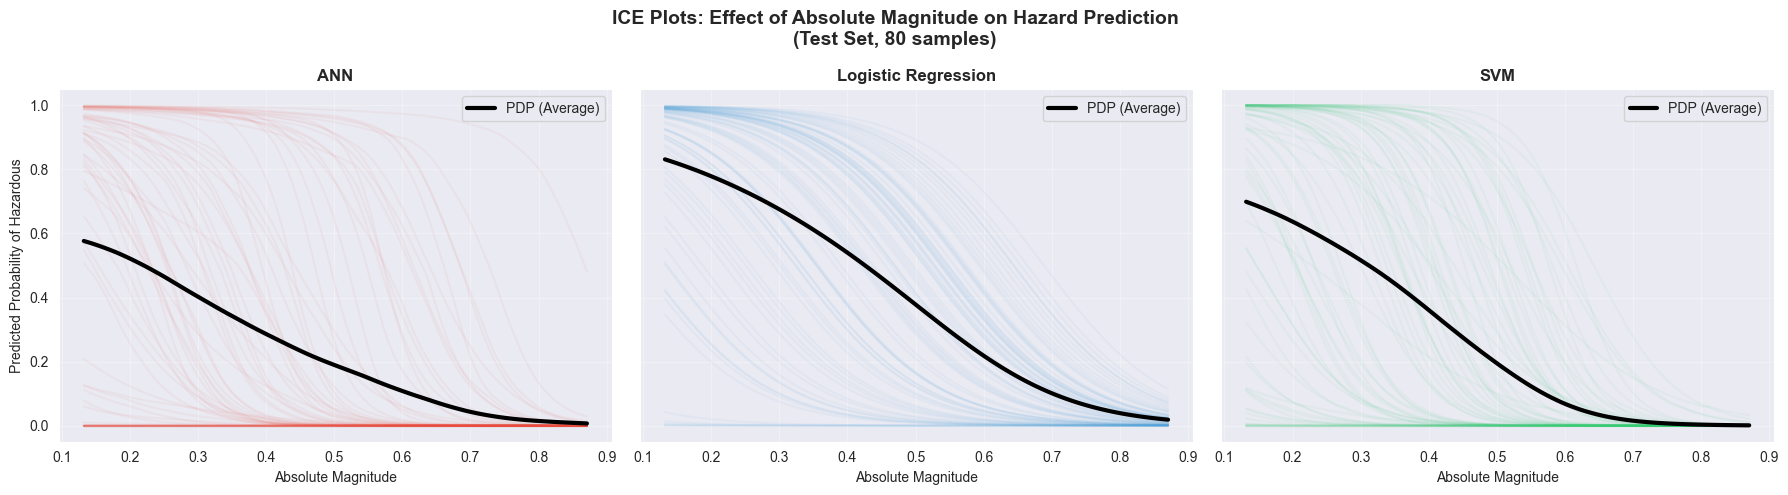

ICE plots generated successfully!
Generating ICE curves for 80 samples and 100 points...


100%|██████████| 80/80 [00:04<00:00, 18.02it/s]


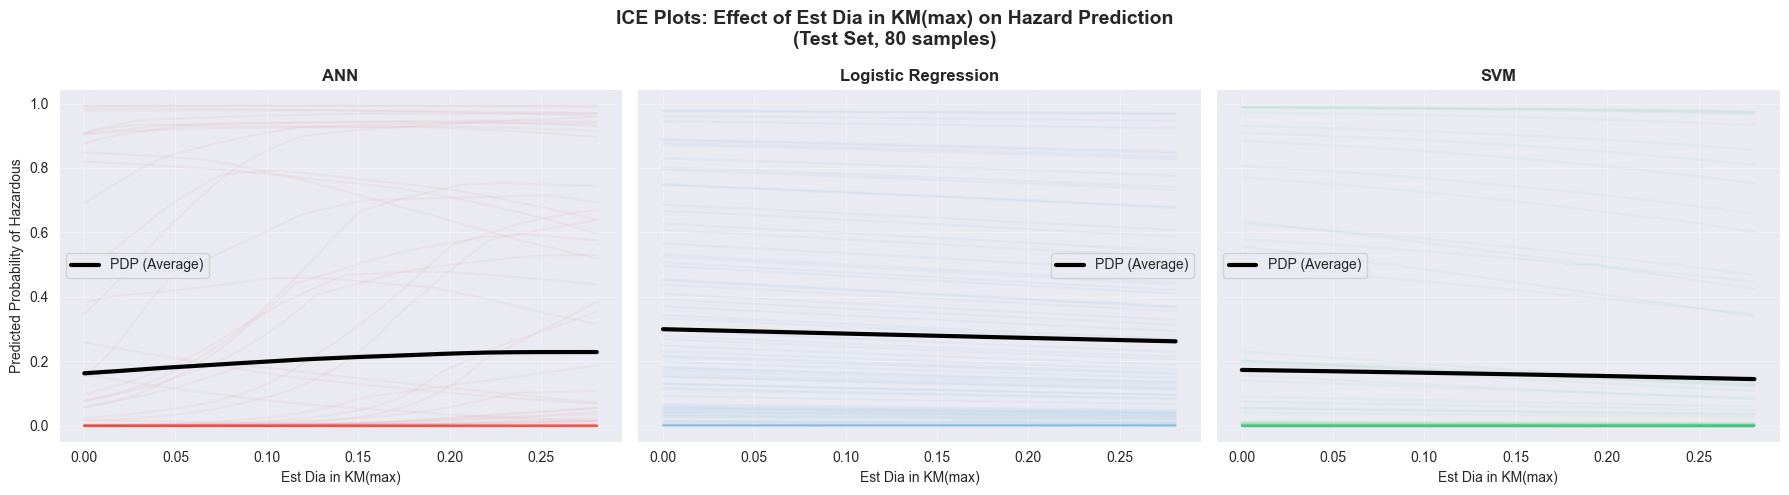

ICE plots generated successfully!
Generating ICE curves for 80 samples and 100 points...


100%|██████████| 80/80 [00:04<00:00, 17.72it/s]


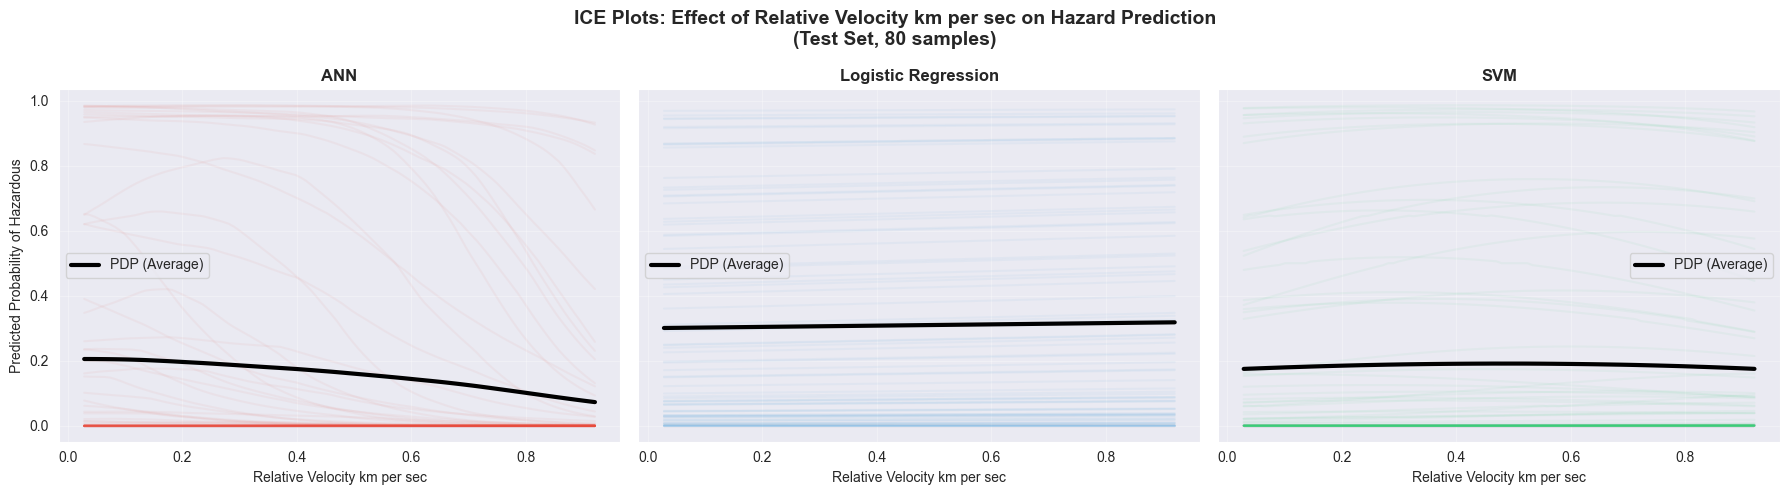

ICE plots generated successfully!
Generating ICE curves for 80 samples and 100 points...


100%|██████████| 80/80 [00:04<00:00, 17.64it/s]


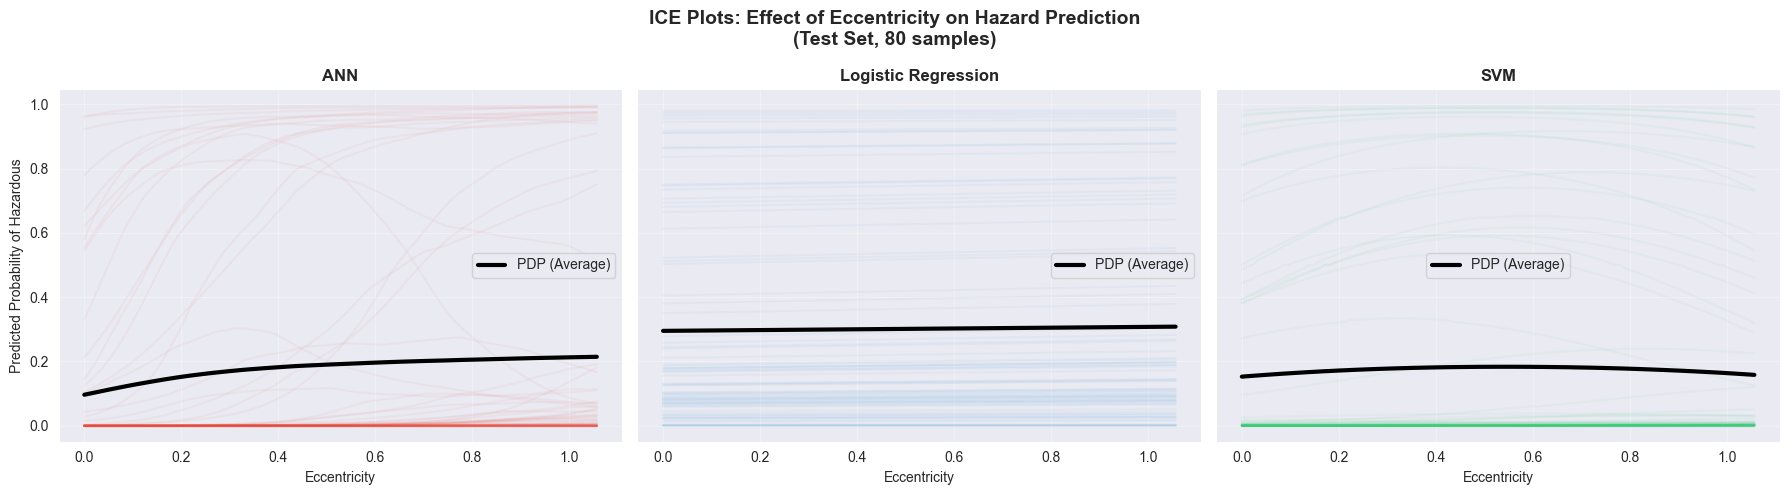

ICE plots generated successfully!


In [21]:
# Generate ICE plots for test set
print("=== ICE PLOTS FOR TEST SET ===")
for feature in interesting_features:
    plot_ice_curves(feature, 'Test', X_test_scaled, y_test, n_samples=80)


=== ICE PLOTS FOR TRAIN SET ===
Generating ICE curves for 80 samples and 100 points...


100%|██████████| 80/80 [00:04<00:00, 17.84it/s]


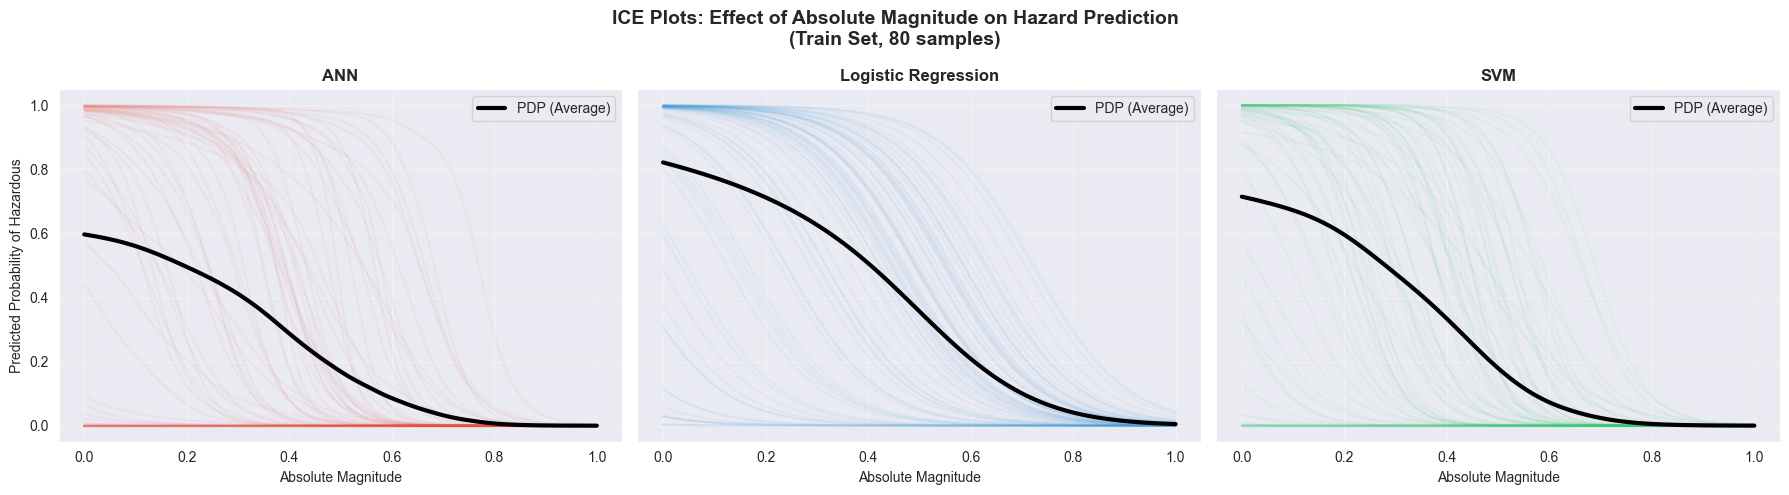

ICE plots generated successfully!
Generating ICE curves for 80 samples and 100 points...


100%|██████████| 80/80 [00:04<00:00, 18.07it/s]


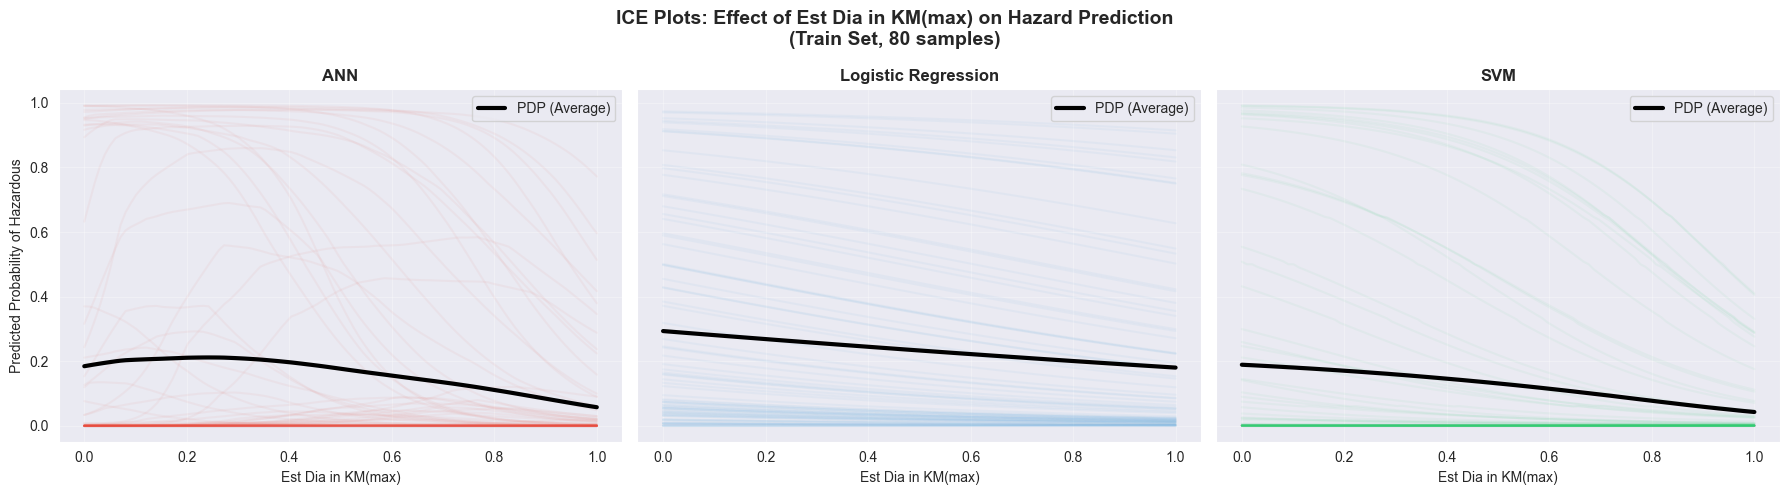

ICE plots generated successfully!
Generating ICE curves for 80 samples and 100 points...


100%|██████████| 80/80 [00:04<00:00, 17.84it/s]


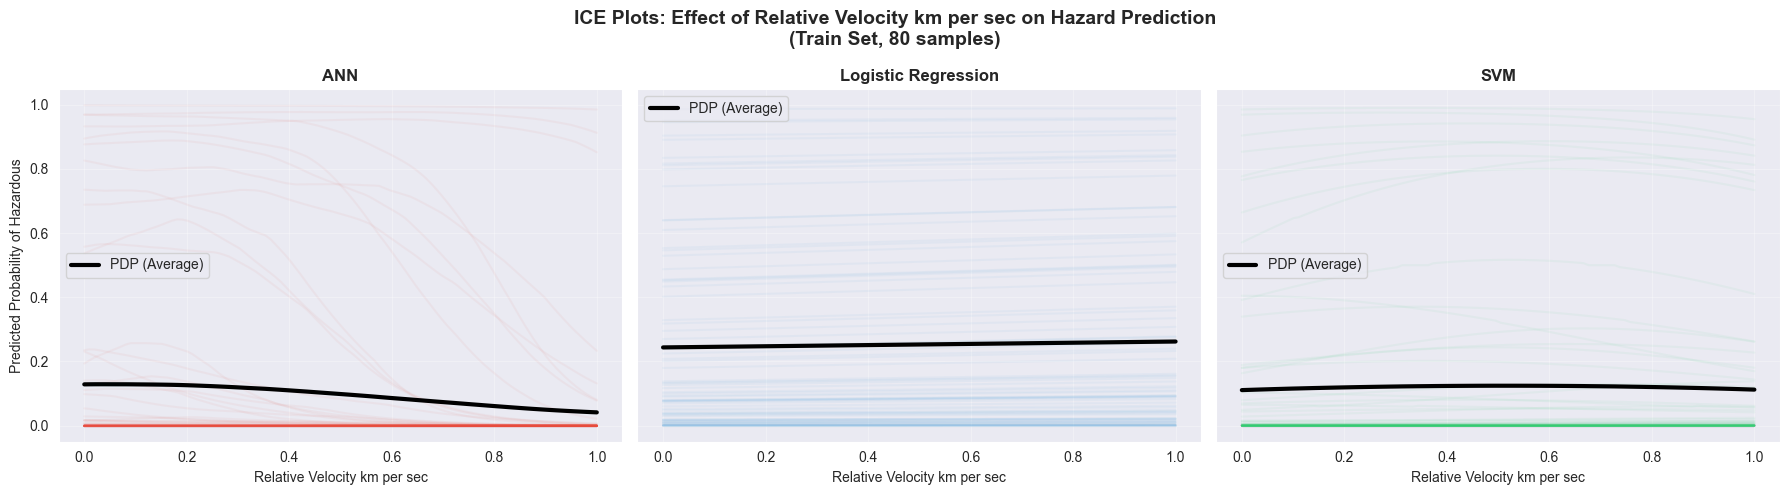

ICE plots generated successfully!
Generating ICE curves for 80 samples and 100 points...


100%|██████████| 80/80 [00:04<00:00, 17.86it/s]


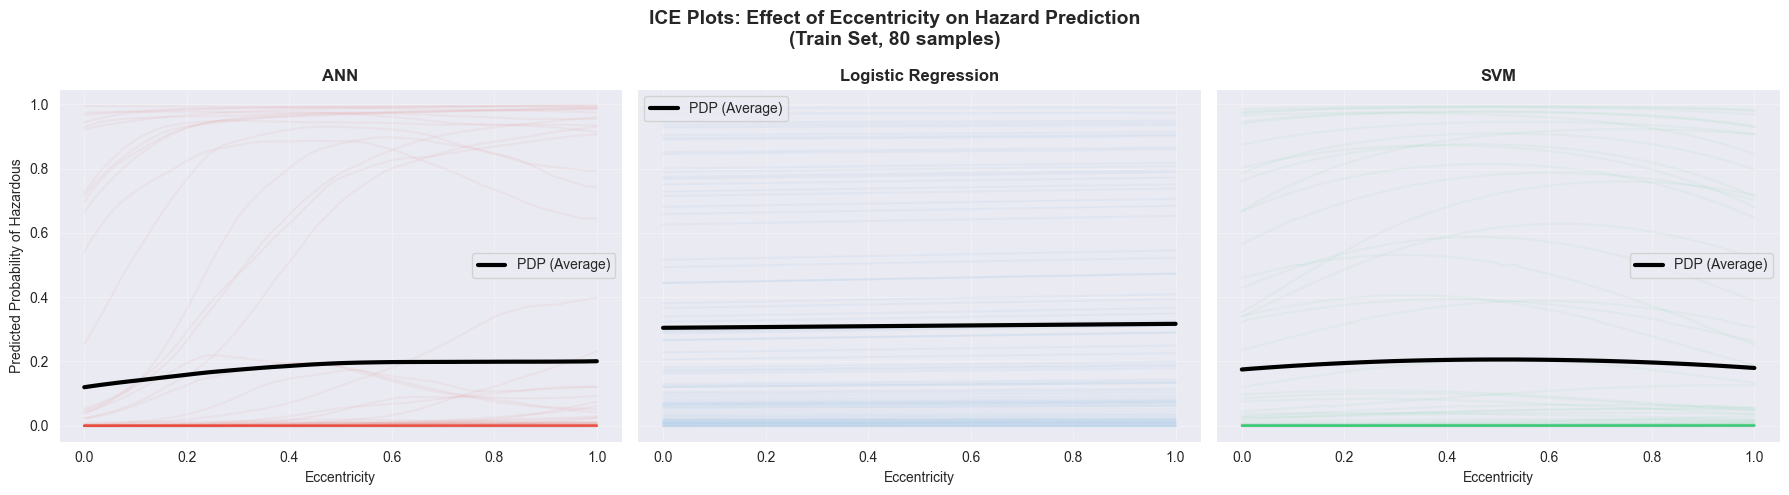

ICE plots generated successfully!


In [22]:
# Generate ICE plots for training set
print("\n=== ICE PLOTS FOR TRAIN SET ===")
for feature in interesting_features:
    plot_ice_curves(feature, 'Train', X_train_scaled, y_train, n_samples=80)

### Observations from ICE Plots

From ICE plots for the selected features:

- **Heterogeneity is present**: individual curves are not identical, so the effect of the same feature depends on the specific object and its other characteristics.
- **Model behavior**: `ANN` has a larger spread of ICE curves (more flexible nonlinear model), `Logistic Regression` curves are more homogeneous, and `SVM` shows moderate spread.
- **PDP as an average trend**: the black average curve captures the overall direction well, but hides part of the local variation visible in ICE.
- **Train vs Test**: ICE structure is generally similar on train and test; no strong degradation or chaotic shape changes are observed on test.
- **Practical takeaway**: use ICE/CP for local decision explanations, and PDP for the global trend.

# 7. Partial Dependence Plot (PDP) - Comprehensive Analysis

## Analysis:

PDP is the average marginal effect of a feature on the prediction.
It shows the expected value of predictions when the feature varies while all others are held at their values.

We'll create PDP plots comparing all three models on the same graph.

In [24]:
def calculate_pdp(feature_name, X_data):
    """
    Calculate Partial Dependence Plot values for all models.
    
    Returns:
        feature_range: Array of feature values
        pdp_ann: ANN predictions
        pdp_lr: Logistic Regression predictions
        pdp_svm: SVM predictions
    """
    # Create feature range
    feature_range = np.linspace(X_data[feature_name].min(), X_data[feature_name].max(), 100)
    
    pdp_ann = []
    pdp_lr = []
    pdp_svm = []
    
    # For each feature value
    for feature_value in feature_range:
        # Create a copy of the data where the feature is fixed
        X_modified = X_data.copy()
        X_modified[feature_name] = feature_value
        
        # Get mean prediction
        pdp_ann.append(ann_model.predict(X_modified, verbose=0).mean())
        pdp_lr.append(lr_model.predict_proba(X_modified)[:, 1].mean())
        pdp_svm.append(svm_model.predict_proba(X_modified)[:, 1].mean())
    
    return feature_range, np.array(pdp_ann), np.array(pdp_lr), np.array(pdp_svm)

print("Calculating PDP values...")

Calculating PDP values...


In [25]:
# Calculate PDP for all features
pdp_data = {}

for feature in interesting_features:
    print(f"Calculating PDP for {feature}...")
    feature_range, pdp_ann, pdp_lr, pdp_svm = calculate_pdp(feature, X_test_scaled)
    pdp_data[feature] = {
        'range': feature_range,
        'ann': pdp_ann,
        'lr': pdp_lr,
        'svm': pdp_svm
    }

print("PDP calculation completed!")

Calculating PDP for Absolute Magnitude...
Calculating PDP for Est Dia in KM(max)...
Calculating PDP for Relative Velocity km per sec...
Calculating PDP for Eccentricity...
PDP calculation completed!


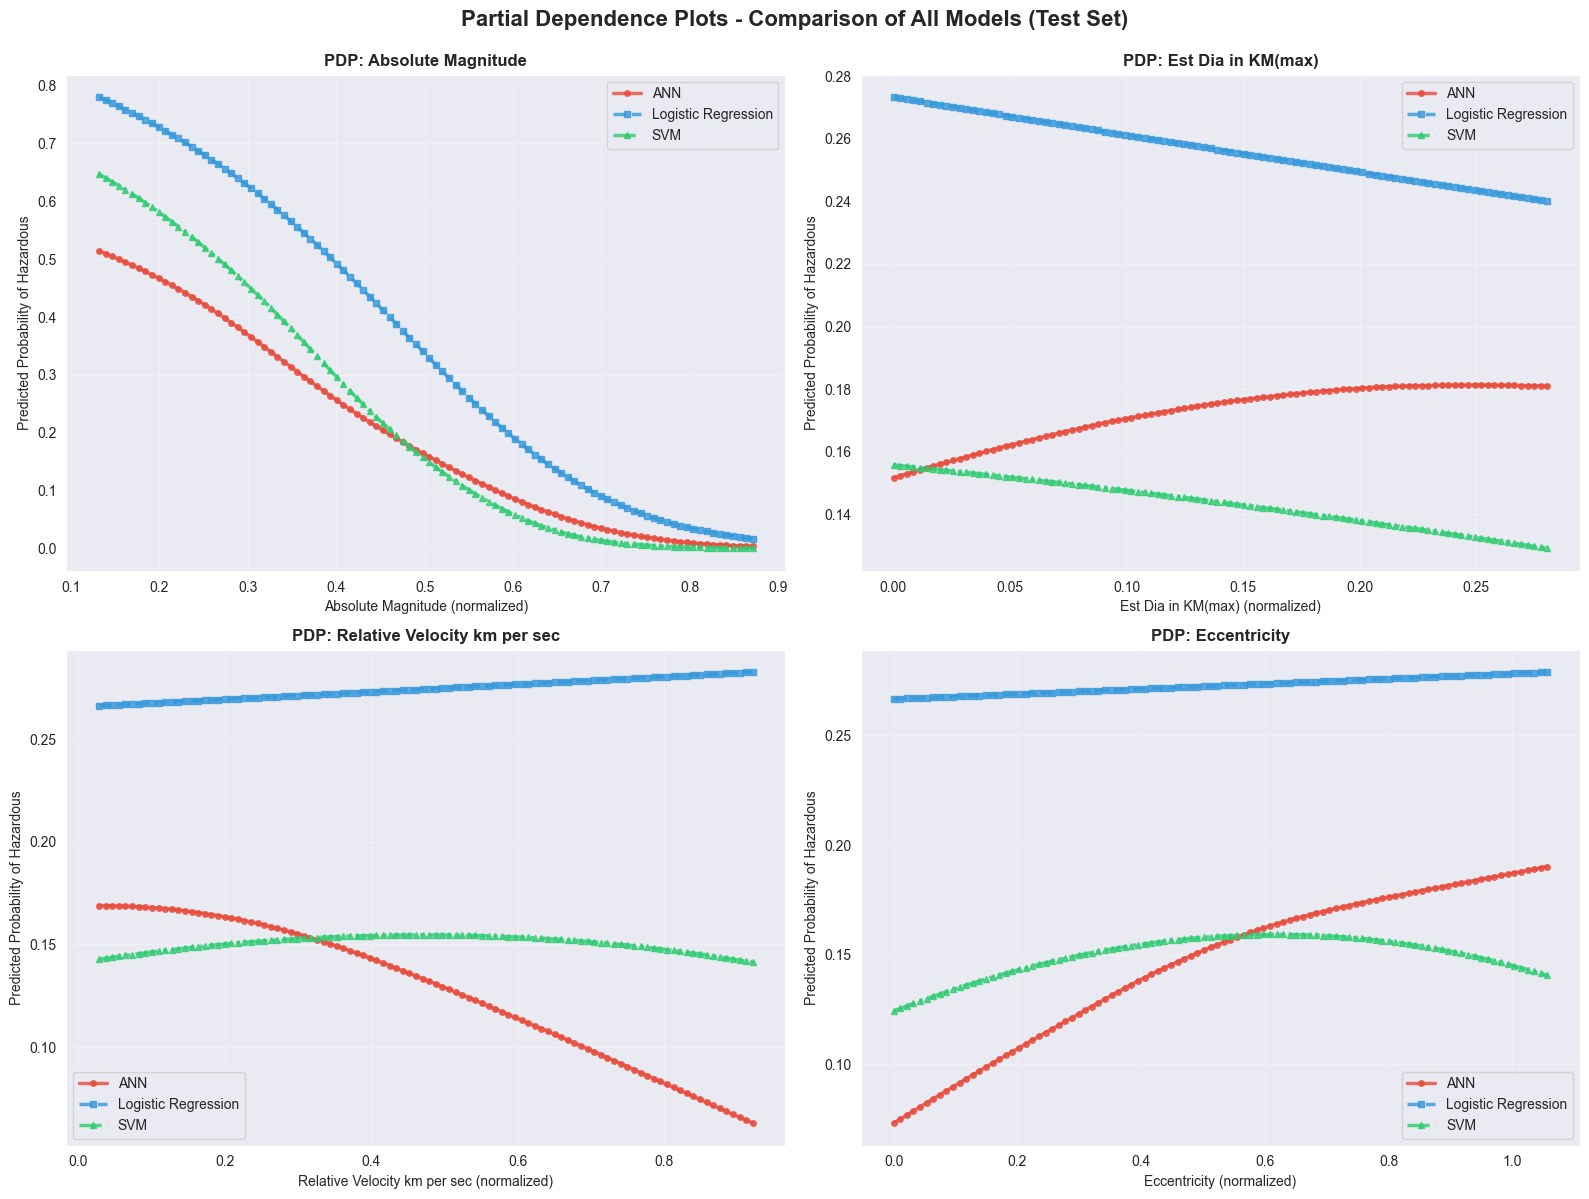

In [26]:
# Plot PDP for all features on one comprehensive plot
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, feature in enumerate(interesting_features):
    ax = axes[idx]
    
    data = pdp_data[feature]
    
    # Plot PDP curves for each model
    ax.plot(data['range'], data['ann'], linewidth=2.5, label='ANN', color='#e74c3c', marker='o', markersize=4, alpha=0.8)
    ax.plot(data['range'], data['lr'], linewidth=2.5, label='Logistic Regression', color='#3498db', marker='s', markersize=4, alpha=0.8, linestyle='--')
    ax.plot(data['range'], data['svm'], linewidth=2.5, label='SVM', color='#2ecc71', marker='^', markersize=4, alpha=0.8, linestyle='-.')
    
    ax.set_title(f'PDP: {feature}', fontsize=12, fontweight='bold')
    ax.set_xlabel(f'{feature} (normalized)')
    ax.set_ylabel('Predicted Probability of Hazardous')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best')

plt.suptitle('Partial Dependence Plots - Comparison of All Models (Test Set)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

### PDP Observations:

1. **Model Agreement**: Do all models have similar PDP curves?
2. **Monotonicity**: Are the curves monotonic or non-linear?
3. **Feature Importance**: Which features show the strongest effects?
4. **Interaction Effects**: Do the patterns suggest feature interactions?

# 8. SHAP (SHapley Additive exPlanations) Analysis

## Overview:

SHAP values are based on cooperative game theory (Shapley values) and provide:
1. **Local explanations**: Why did the model make a specific prediction for a single instance?
2. **Global explanations**: Which features are most important overall?
3. **Strong theoretical foundation**: Based on Shapley values from game theory

We'll use SHAP with SVM model as it's computationally efficient.

In [27]:
# Initialize SHAP
print("Initializing SHAP for SVM model...")
shap.initjs()

# Create prediction function for SHAP
def svm_predict_proba(X):
    if not isinstance(X, pd.DataFrame):
        X = pd.DataFrame(X, columns=X_test_scaled.columns)
    return svm_model.predict_proba(X)[:, 1]

# Create background data for SHAP (use random sample for efficiency)
background_data = shap.sample(X_test_scaled, min(200, len(X_test_scaled)), random_state=42)

# Create SHAP explainer
print(f"Creating SHAP explainer with {len(background_data)} background samples...")
explainer_svm = shap.Explainer(svm_predict_proba, background_data)

print("SHAP explainer created!")

Initializing SHAP for SVM model...


Creating SHAP explainer with 200 background samples...
SHAP explainer created!


In [29]:
# Calculate SHAP values for test set
print("Calculating SHAP values for test set samples...")

# Use a subset for analysis (for computational efficiency)
n_explain = min(200, len(X_test_scaled))
X_test_explain = X_test_scaled.iloc[:n_explain]

shap_values_svm = explainer_svm(X_test_explain)

print(f"\nSHAP values calculated for {n_explain} test samples!")
print(f"SHAP values shape: {shap_values_svm.values.shape}")

Calculating SHAP values for test set samples...


PermutationExplainer explainer: 201it [12:31,  3.79s/it]                         


SHAP values calculated for 200 test samples!
SHAP values shape: (200, 29)


=== LOCAL EXPLANATIONS ===

Waterfall Plot - How did the model predict for a specific instance?


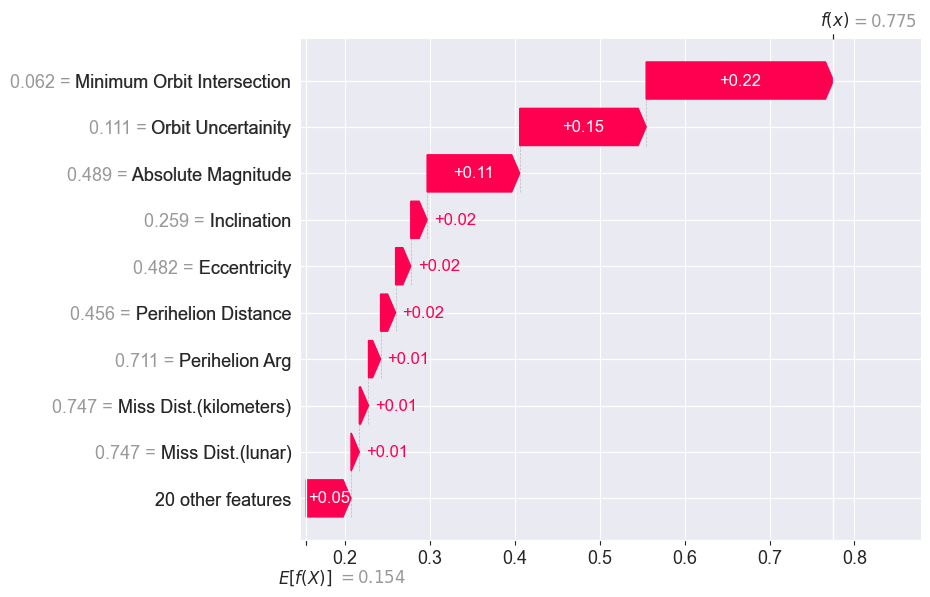

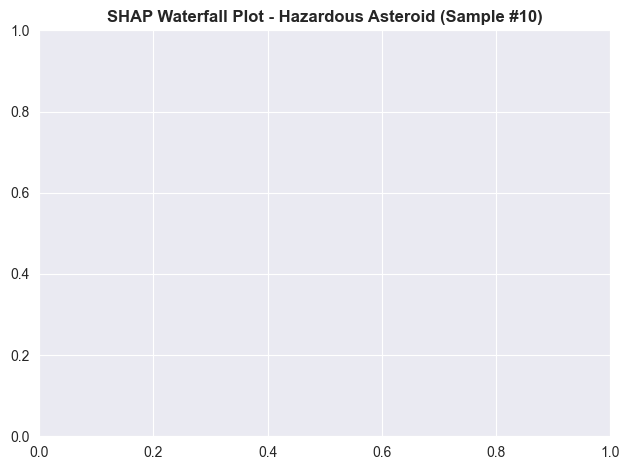


Sample #10 explained:
- Actual target: 1
- Prediction: 0.7753


In [30]:
# 8.1 Local Explanations - Waterfall Plot for a single instance
print("=== LOCAL EXPLANATIONS ===")
print("\nWaterfall Plot - How did the model predict for a specific instance?")

plt.figure(figsize=(12, 6))
# Plot for a hazardous asteroid
hazardous_idx = np.where(y_test.iloc[:n_explain].values == 1)[0][0]
shap.plots.waterfall(shap_values_svm[hazardous_idx])
plt.title(f'SHAP Waterfall Plot - Hazardous Asteroid (Sample #{hazardous_idx})', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nSample #{hazardous_idx} explained:")
print(f"- Actual target: {y_test.iloc[hazardous_idx]}")
print(f"- Prediction: {svm_model.predict_proba(X_test_scaled.iloc[[hazardous_idx]])[0, 1]:.4f}")

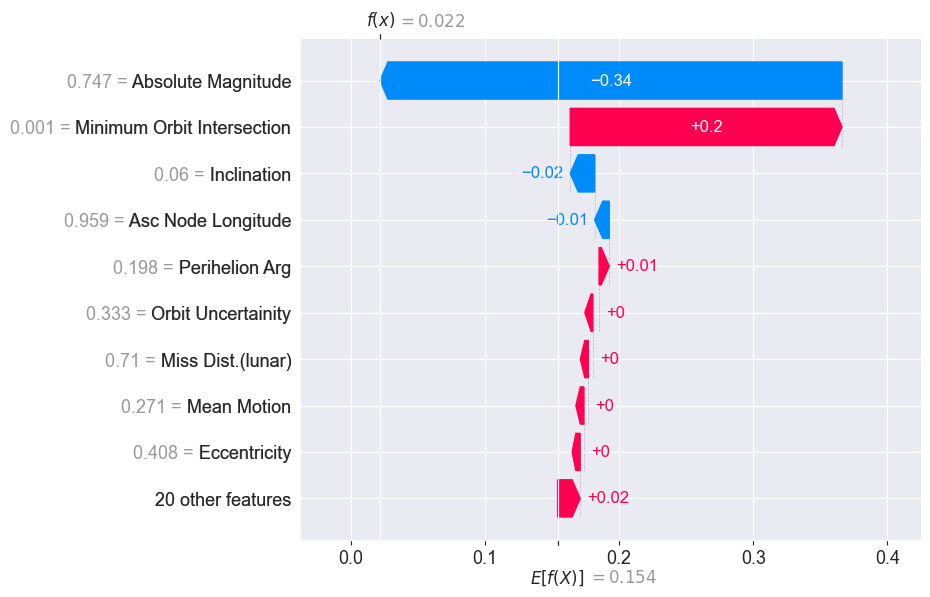

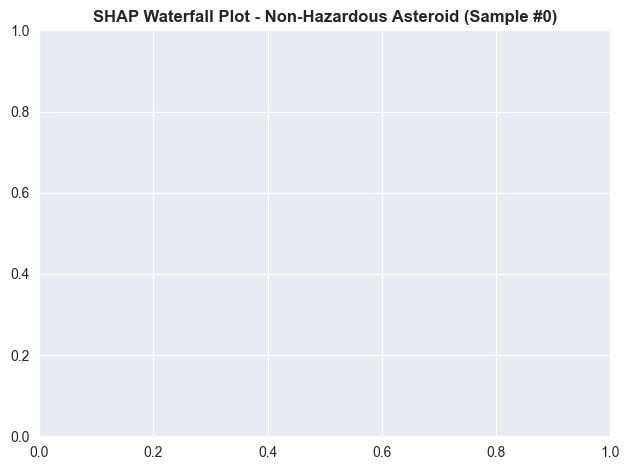


Sample #0 explained:
- Actual target: 0
- Prediction: 0.0216


In [31]:
# Plot for a non-hazardous asteroid
plt.figure(figsize=(12, 6))
non_hazardous_idx = np.where(y_test.iloc[:n_explain].values == 0)[0][0]
shap.plots.waterfall(shap_values_svm[non_hazardous_idx])
plt.title(f'SHAP Waterfall Plot - Non-Hazardous Asteroid (Sample #{non_hazardous_idx})', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nSample #{non_hazardous_idx} explained:")
print(f"- Actual target: {y_test.iloc[non_hazardous_idx]}")
print(f"- Prediction: {svm_model.predict_proba(X_test_scaled.iloc[[non_hazardous_idx]])[0, 1]:.4f}")


=== GLOBAL EXPLANATIONS ===

Beeswarm Plot - Which features matter most and their effects?


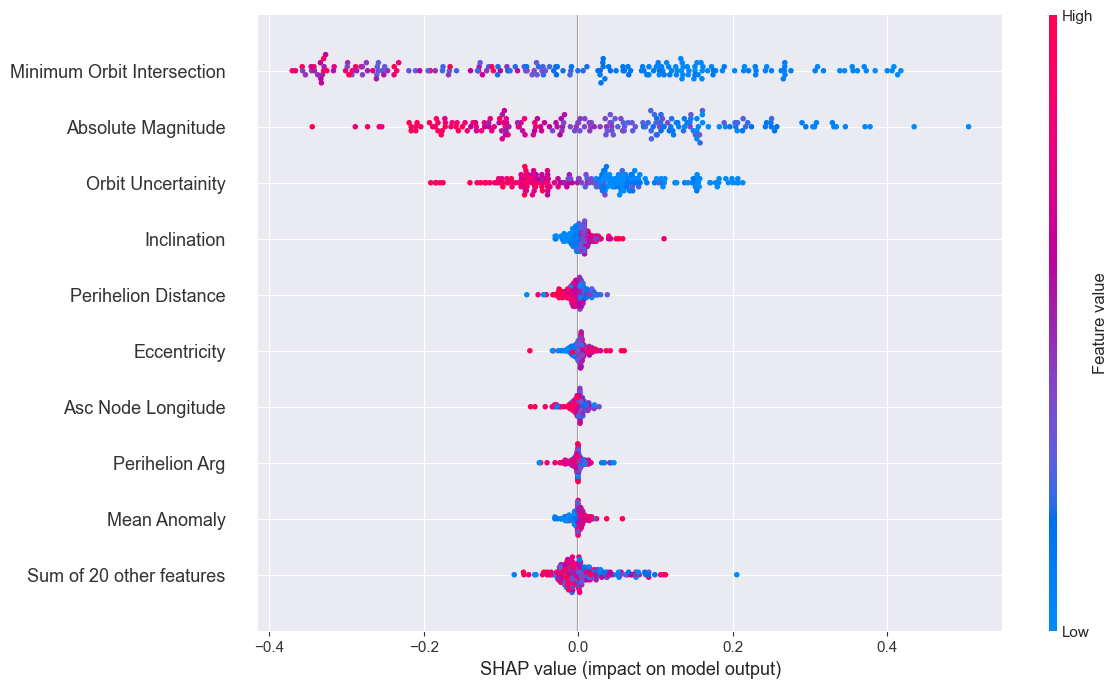

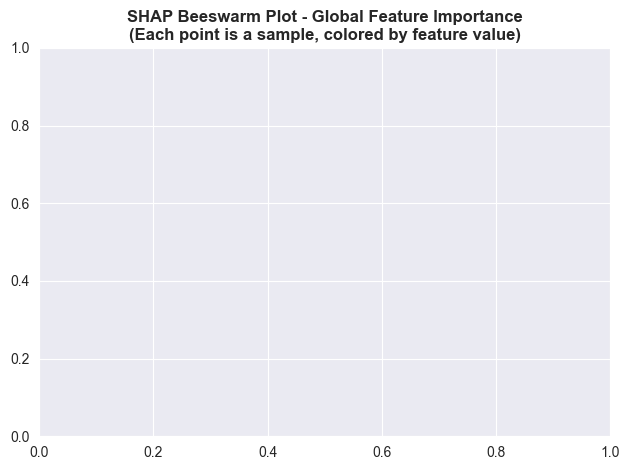


Interpretation:
- X-axis: SHAP value (impact on model output)
- Color: Feature value (red=high, blue=low)
- Position: Feature importance ranking


In [32]:
# 8.2 Global Explanations - Beeswarm Plot (Feature Importance with Direction)
print("\n=== GLOBAL EXPLANATIONS ===")
print("\nBeeswarm Plot - Which features matter most and their effects?")

plt.figure(figsize=(12, 8))
shap.plots.beeswarm(shap_values_svm, plot_size=(12, 8))
plt.title('SHAP Beeswarm Plot - Global Feature Importance\n(Each point is a sample, colored by feature value)', 
          fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- X-axis: SHAP value (impact on model output)")
print("- Color: Feature value (red=high, blue=low)")
print("- Position: Feature importance ranking")


Bar Plot - Mean Absolute SHAP Values


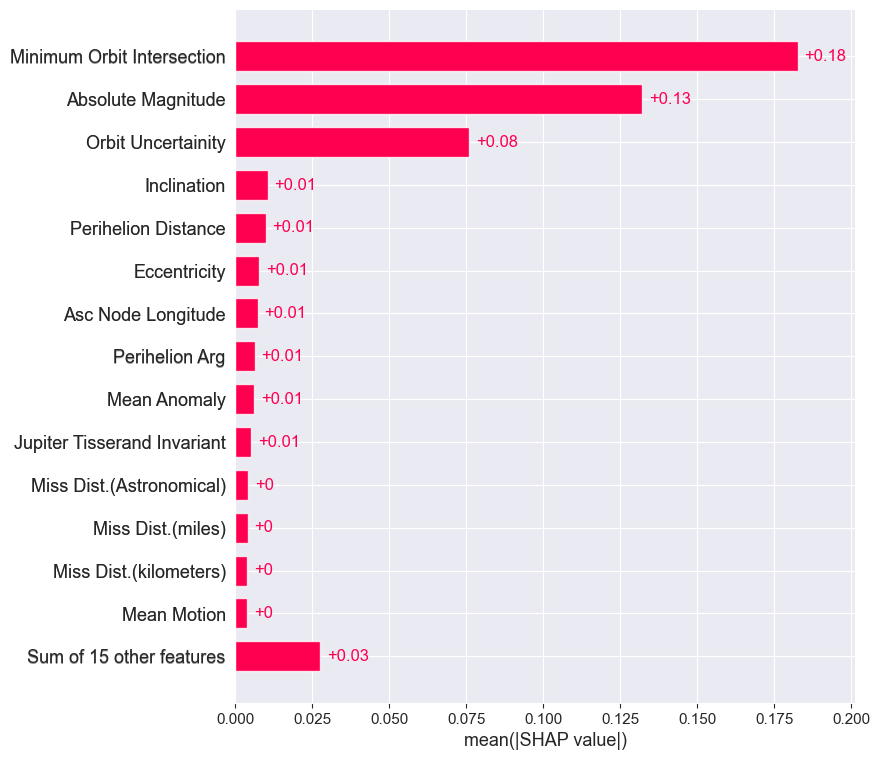

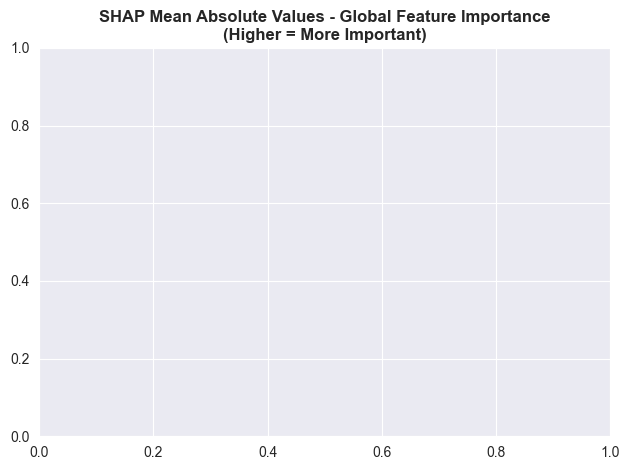

In [33]:
# 8.3 Global Importance Bar Plot
print("\nBar Plot - Mean Absolute SHAP Values")

plt.figure(figsize=(12, 6))
shap.plots.bar(shap_values_svm, max_display=15)
plt.title('SHAP Mean Absolute Values - Global Feature Importance\n(Higher = More Important)', 
          fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()


Dependence Plots - Feature value vs SHAP value (interaction effects)


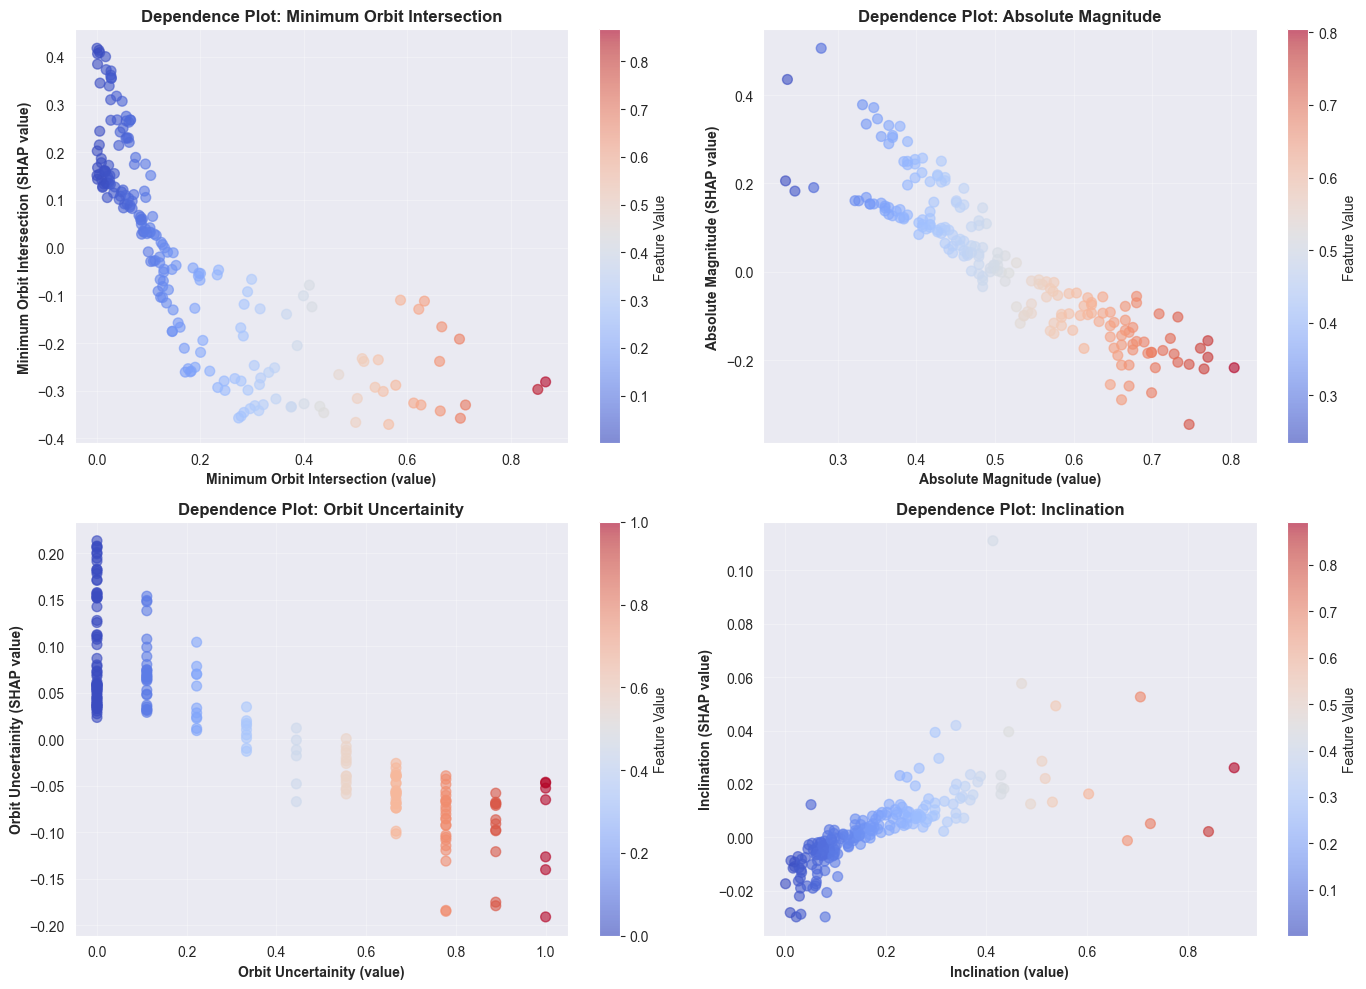

In [34]:
# 8.4 Dependence Plots - Relationship between feature and its SHAP value
print("\nDependence Plots - Feature value vs SHAP value (interaction effects)")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Get top 4 important features
feature_importance = np.abs(shap_values_svm.values).mean(axis=0)
top_features_idx = np.argsort(feature_importance)[-4:][::-1]
top_features = [X_test_scaled.columns[i] for i in top_features_idx]

for idx, feature in enumerate(top_features):
    ax = axes[idx]
    feature_idx = X_test_scaled.columns.get_loc(feature)
    
    # Create scatter plot
    scatter = ax.scatter(shap_values_svm.data[:, feature_idx], 
                         shap_values_svm.values[:, feature_idx],
                         c=shap_values_svm.data[:, feature_idx],
                         cmap='coolwarm', s=50, alpha=0.6)
    
    ax.set_xlabel(f'{feature} (value)', fontweight='bold')
    ax.set_ylabel(f'{feature} (SHAP value)', fontweight='bold')
    ax.set_title(f'Dependence Plot: {feature}', fontweight='bold')
    ax.grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=ax, label='Feature Value')

plt.tight_layout()
plt.show()

In [35]:
# Print top 10 most important features
feature_importance = np.abs(shap_values_svm.values).mean(axis=0)
top_indices = np.argsort(feature_importance)[-10:][::-1]

print("\n=== TOP 10 MOST IMPORTANT FEATURES (by SHAP) ===")
for rank, idx in enumerate(top_indices, 1):
    feature_name = X_test_scaled.columns[idx]
    importance_score = feature_importance[idx]
    print(f"{rank:2}. {feature_name:40s} : {importance_score:.6f}")


=== TOP 10 MOST IMPORTANT FEATURES (by SHAP) ===
 1. Minimum Orbit Intersection               : 0.182715
 2. Absolute Magnitude                       : 0.132190
 3. Orbit Uncertainity                       : 0.075930
 4. Inclination                              : 0.010454
 5. Perihelion Distance                      : 0.009818
 6. Eccentricity                             : 0.007671
 7. Asc Node Longitude                       : 0.007207
 8. Perihelion Arg                           : 0.006346
 9. Mean Anomaly                             : 0.006131
10. Jupiter Tisserand Invariant              : 0.005193


# 9. Comparison of Interpretability Methods

## Methods Comparison Table

In [36]:
# Create comparison table
comparison_table = pd.DataFrame({
    'Method': ['Ceteris Paribus (CP)', 'Individual Conditional Expectation (ICE)', 
               'Partial Dependence (PDP)', 'SHAP'],
    'Type': ['Local', 'Local', 'Global', 'Local & Global'],
    'What it shows': [
        'How prediction changes when we vary one feature (1 sample)',
        'How prediction changes for EACH sample separately',
        'Average effect of a feature across all samples',
        'Contribution of each feature to each prediction'
    ],
    'Computational Cost': ['Low', 'Medium', 'Medium', 'High'],
    'Model Type': ['Any', 'Any', 'Any', 'Any'],
    'Strengths': [
        'Simple, intuitive, model-agnostic',
        'Shows heterogeneity, reveals patterns',
        'Global view, easy to interpret',
        'Theoretically grounded, consistent, local+global'
    ]
})

print("="*150)
print("INTERPRETABILITY METHODS COMPARISON")
print("="*150)
print(comparison_table.to_string(index=False))
print("="*150)

INTERPRETABILITY METHODS COMPARISON
                                  Method           Type                                              What it shows Computational Cost Model Type                                        Strengths
                    Ceteris Paribus (CP)          Local How prediction changes when we vary one feature (1 sample)                Low        Any                Simple, intuitive, model-agnostic
Individual Conditional Expectation (ICE)          Local          How prediction changes for EACH sample separately             Medium        Any            Shows heterogeneity, reveals patterns
                Partial Dependence (PDP)         Global             Average effect of a feature across all samples             Medium        Any                   Global view, easy to interpret
                                    SHAP Local & Global            Contribution of each feature to each prediction               High        Any Theoretically grounded, consistent, local+g

# 10. Key Findings & Analysis

In [37]:
# Summary statistics for analysis
print("\n" + "="*80)
print("SUMMARY OF ANALYSIS")
print("="*80)

print(f"\n1. DATASET INFORMATION:")
print(f"   - Total samples: {len(df)}")
print(f"   - Features used: {X_train_scaled.shape[1]}")
print(f"   - Training samples: {len(X_train_scaled)}")
print(f"   - Testing samples: {len(X_test_scaled)}")
print(f"   - Hazardous asteroids: {y_test.sum()} in test set ({y_test.mean()*100:.1f}%)")
print(f"   - Non-hazardous asteroids: {(1-y_test).sum()} in test set ({(1-y_test).mean()*100:.1f}%)")

print(f"\n2. MODEL PERFORMANCE:")
print(comparison_df.to_string(index=False))

print(f"\n3. TOP IMPORTANT FEATURES (by SHAP):")
for rank, idx in enumerate(top_indices[:5], 1):
    feature_name = X_test_scaled.columns[idx]
    importance_score = feature_importance[idx]
    print(f"   {rank}. {feature_name}: {importance_score:.6f}")


SUMMARY OF ANALYSIS

1. DATASET INFORMATION:
   - Total samples: 4687
   - Features used: 29
   - Training samples: 3749
   - Testing samples: 938
   - Hazardous asteroids: 151 in test set (16.1%)
   - Non-hazardous asteroids: 787 in test set (83.9%)

2. MODEL PERFORMANCE:
              Model  Train Accuracy  Test Accuracy  Train AUC  Test AUC
                ANN        0.978394       0.974414   0.996802  0.993807
Logistic Regression        0.897573       0.896588   0.975132  0.972820
                SVM        0.899440       0.894456   0.987695  0.979413

3. TOP IMPORTANT FEATURES (by SHAP):
   1. Minimum Orbit Intersection: 0.182715
   2. Absolute Magnitude: 0.132190
   3. Orbit Uncertainity: 0.075930
   4. Inclination: 0.010454
   5. Perihelion Distance: 0.009818


# 11. CONCLUSIONS

- On the NASA dataset, the best result was achieved by **ANN**: `Accuracy = 0.974`, `AUC = 0.994`.
- **Logistic Regression** and **SVM** produced similar results (`Accuracy ≈ 0.90`, `AUC ≈ 0.97–0.98`), but both were lower than ANN.
- According to SHAP (for SVM), the most important features are **Minimum Orbit Intersection**, **Absolute Magnitude**, and **Orbit Uncertainity**.
- CP/ICE/PDP show a consistent picture: there are local differences across objects, but global trends are stable.
- **Why compare Train and Test for interpretation**: Train explanations show what the model learned/memorized during training; Test explanations show how the model behaves on unseen data. In our case, CP/ICE shapes on test are close to train, so no clear signs of overfitting were found in the explanations.
- For this task, the practical choice is **ANN** for prediction + **SHAP** for explaining results.